## HR Analytics: Optimizing Personnel Management

### Project Objectives

1. **Reducing Turnover Rates**

    Using predictive analytics to identify employees with low satisfaction and high turnover risk, enabling timely interventions to retain key talent.
    
    
2. **Improving Personnel Management**

    Automating employee data analysis with machine learning to reduce time on routine tasks and improve HR decision accuracy.
    
    
3. **Reducing Financial Losses from Turnover**

    Predicting satisfaction and turnover probability helps minimize losses from valuable employee departures and reduce hiring and training costs.
    
    
4. **Improving HR Strategy Effectiveness**

    Data analysis enables HR to better understand employee needs, helping develop more accurate and effective programs to boost motivation and engagement.
    
    
5. **Building an Attractive Employer Brand**

    Timely response to employee requests and expectations builds trust and loyalty, improving company reputation in the job market and attracting more talented candidates.

In [1]:
import os
os.makedirs('reports/images', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder, 
    StandardScaler, 
    MinMaxScaler,
    LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import (
    Ridge,
    LinearRegression,
    LogisticRegression
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    make_scorer,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
import shap
from sklearn.base import (
    BaseEstimator,
    TransformerMixin
)
import time

In [2]:
# Constants
RANDOM_STATE = 42
VALID_SIZE = 0.25

## Task 1: Predicting Employee Satisfaction Level

### Data Description

- `id` — unique employee identifier;
- `dept` — department where employee works;
- `level` — position level;
- `workload` — employee workload level;
- `employment_years` — tenure at company (in years);
- `last_year_promo` — indicates promotion in last year;
- `last_year_violations` — indicates contract violations in last year;
- `supervisor_evaluation` — supervisor's assessment of employee work quality;
- `salary` — monthly employee salary;
- `job_satisfaction_rate` — employee satisfaction level, target variable.

#### Data Loading

In [3]:
# Load data from csv files
train_job_satisfaction_rate = pd.read_csv('../../datasets/train_job_satisfaction_rate.csv', index_col='id')
test_features = pd.read_csv('../../datasets/test_features.csv', index_col='id')
test_target_job_satisfaction_rate = pd.read_csv('../../datasets/test_target_job_satisfaction_rate.csv', index_col='id')

Let's look at the first rows of each dataset for visual assessment

In [4]:
train_job_satisfaction_rate.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


In [5]:
test_features.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000
467458,sales,middle,low,5,no,no,4,19200
418655,sales,middle,low,6,no,no,4,19200
789145,hr,middle,medium,5,no,no,5,40800


In [6]:
test_target_job_satisfaction_rate.head()

,job_satisfaction_rate
id,
130604,0.74
825977,0.75
418490,0.60
555320,0.72
826430,0.08


#### Data Analysis

Let's examine general information about each dataset

In [7]:
train_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 155278 to 338347
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   3994 non-null   object 
 1   level                  3996 non-null   object 
 2   workload               4000 non-null   object 
 3   employment_years       4000 non-null   int64  
 4   last_year_promo        4000 non-null   object 
 5   last_year_violations   4000 non-null   object 
 6   supervisor_evaluation  4000 non-null   int64  
 7   salary                 4000 non-null   int64  
 8   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 312.5+ KB


Data `train_job_satisfaction_rate` contains several missing values. Data types are correct.

In [8]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 485046 to 771859
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


Data `test_features` also contains several missing values. Data types are correct.

In [9]:
test_target_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 130604 to 648995
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1)
memory usage: 31.2 KB


Data `test_target_job_satisfaction_rate` has no missing values. Data types are correct.

#### Summary

Data from all provided files loaded successfully. Data formats match description. Some columns contain missing values which will be handled during preprocessing. Data types are correct.

### Data Preprocessing

#### Handling Missing Values

In [10]:
# Display rows train_job_satisfaction_rate with missing values
train_job_satisfaction_rate[(train_job_satisfaction_rate['dept'].isna())
                            | (train_job_satisfaction_rate['dept'].str.strip() == "")
                            | (train_job_satisfaction_rate['level'].isna())
                            | (train_job_satisfaction_rate['level'].str.strip() == "")]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
631073,sales,NaN,medium,1,no,no,4,27600,0.66
416327,sales,NaN,low,1,no,no,5,18000,0.73
694746,NaN,junior,medium,5,no,no,4,21600,0.62
814624,NaN,junior,medium,3,no,no,4,24000,0.88
475114,NaN,junior,high,4,no,no,4,31200,0.63
135043,sales,NaN,medium,1,no,no,3,26400,0.30
998838,sales,NaN,medium,1,no,no,5,27600,0.71
497243,NaN,junior,medium,1,no,no,3,26400,0.28
168668,NaN,junior,low,3,no,no,4,18000,0.88


In [11]:
# Display rows test_features with missing values
test_features[(test_features['dept'].isna())
              | (test_features['dept'].str.strip() == "")
              | (test_features['level'].isna())
              | (test_features['level'].str.strip() == "")]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
609865,NaN,junior,medium,1,no,no,1,20400
471990,sales,NaN,low,1,no,no,3,12000
832342,NaN,junior,medium,1,no,no,4,28800
822186,,middle,medium,3,no,no,4,38400


For handling explicit and implicit missing values we'll create a custom transformer to be used in the pipeline. For promotion universality, first let's check data on duplicates, that at if needed, include processing allpotential data problems in one step.

#### Handling Implicit Duplicates

When searching for implicit duplicates and typos, we compare corresponding columns of train and test datasets to ensure consistency.

In [12]:
# Explore values of column dept in dataset train_job_satisfaction_rate
train_job_satisfaction_rate['dept'].value_counts()

dept
sales         1512
technology     866
purchasing     610
marketing      550
hr             456
Name: count, dtype: int64

In [13]:
# Explore values of column dept in dataset test_features
test_features['dept'].value_counts()

dept
sales         763
technology    455
marketing     279
purchasing    273
hr            227
                1
Name: count, dtype: int64

No implicit duplicates found in `dept` column. Categories match in datasets and are proportionally equal.

In [14]:
# Explore values of column level in dataset train_job_satisfaction_rate
train_job_satisfaction_rate['level'].value_counts()

level
junior    1894
middle    1744
sinior     358
Name: count, dtype: int64

In [15]:
# Explore values of column level in dataset test_features
test_features['level'].value_counts()

level
junior    974
middle    854
sinior    171
Name: count, dtype: int64

No implicit duplicates found, categories match. However, category `sinior` has a typo. We'll fix this in the transformer.

In [16]:
# Explore values of column workload in dataset train_job_satisfaction_rate
train_job_satisfaction_rate['workload'].value_counts()

workload
medium    2066
low       1200
high       734
Name: count, dtype: int64

In [17]:
# Explore values of column workload in dataset test_features
test_features['workload'].value_counts()

workload
medium    1043
low        593
high       363
             1
Name: count, dtype: int64

We'll account for the implicit missing value in `workload` column in `test_features` dataset during processing

In [18]:
# Explore values of column last_year_promo in dataset train_job_satisfaction_rate
train_job_satisfaction_rate['last_year_promo'].value_counts()

last_year_promo
no     3880
yes     120
Name: count, dtype: int64

In [19]:
# Explore values of column last_year_promo in dataset test_features
test_features['last_year_promo'].value_counts()

last_year_promo
no     1937
yes      63
Name: count, dtype: int64

No implicit duplicates in `last_year_promo` column, categories match.

In [20]:
# Explore values of column last_year_violations in dataset train_job_satisfaction_rate
train_job_satisfaction_rate['last_year_violations'].value_counts()

last_year_violations
no     3441
yes     559
Name: count, dtype: int64

In [21]:
# Explore values of column last_year_violations in dataset test_features
test_features['last_year_violations'].value_counts()

last_year_violations
no     1738
yes     262
Name: count, dtype: int64

No implicit duplicates in `last_year_violations` column, categories match.

#### Handling Explicit Duplicates

In [22]:
# Check for explicit duplicates in dataset train_job_satisfaction_rate
train_job_satisfaction_rate.duplicated().sum()

245

In [23]:
# Check for explicit duplicates in dataset test_features
test_features.duplicated().sum()

557

In [24]:
# Check for explicit duplicates in dataset test_features
test_target_job_satisfaction_rate.duplicated().sum()

1902

No explicit duplicates found in data, we can proceed.

#### Creating Data Transformer

In [25]:
class CustomDataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, group_by, typo_corrections=None):
        self.group_by = group_by
        self.typo_corrections = typo_corrections if typo_corrections else {}
        self.group_mode = {}

    def fit(self, X, y=None):        
        X = X.copy()
        X = X.replace(['', ' '], np.nan)

        for group, cols in self.group_by.items():
            self.group_mode[group] = {}
            grouped_data = X.groupby(group)
            for col in cols:
                self.group_mode[group][col] = grouped_data[col].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None).to_dict()

        return self

    def transform(self, X):
        X = X.copy()
        X = X.replace(['', ' '], np.nan)

        # Fix typos
        for col, corrections in self.typo_corrections.items():
            if col in X.columns:
                X[col] = X[col].replace(corrections)

        # Fill missing values in group (e.g., dept) with mode
        for group in self.group_by:
            if group in X.columns:
                mode_value = X[group].mode().iloc[0] if not X[group].mode().empty else None
                X.loc[X[group].isna(), group] = mode_value

        # Fill missing values in other columns with group modes
        for group, cols in self.group_by.items():
            for col in cols:
                for dept, mode_value in self.group_mode[group][col].items():
                    mask = (X[group] == dept) & (X[col].isna())
                    X.loc[mask, col] = mode_value

        return X


Let's test the transformer on sample data before using it in the pipeline.

In [26]:
# Sample data
data = pd.DataFrame({
    'dept': ['sales', 'sales', 'technlogy', 'marketing', '', 'marketing'],
    'level': ['junior', np.nan, 'middle', '', 'sinior', 'senior'],
    'workload': ['low', np.nan, 'high', 'medium', '', '']
})

# Sample parameters
typo_corrections = {
    'level': {'sinior': 'senior'},
    'dept': {'technlogy': 'technology'}
}
group_by = {'dept': ['level', 'workload']}

# Create and apply transformer
cleaner = CustomDataCleaner(group_by, typo_corrections=typo_corrections)
cleaned_data = cleaner.fit_transform(data)

cleaned_data

,dept,level,workload
0,sales,junior,low
1,sales,junior,low
2,technology,middle,high
3,marketing,senior,medium
4,marketing,senior,medium
5,marketing,senior,medium


Test data processed correctly. We'll use this transformer in the preprocessing step of modeling.

#### Conclusions

The following preprocessing steps were performed:

1. **Missing value search**: All explicit and implicit missing values identified. Created `CustomDataCleaner` class for automated handling in pipeline.
2. **Duplicate check**: No duplicates found in datasets.

As a result of preprocessing, data is prepared for further analysis and modeling. All identified errors are handled in the automated transformer.

### Exploratory Data Analysis

To assess data consistency, we'll combine train and test datasets into one for subsequent analysis, marking them with different categories.

In [27]:
# Add category "sample" to train and test data
train_analysis = train_job_satisfaction_rate.copy()
train_analysis['dataset'] = 'Train data'

test_analysis = test_features.merge(test_target_job_satisfaction_rate, on='id', how='left')
test_analysis['dataset'] = 'Test data'

# Combine data for visualization
analysis_data = pd.concat([train_analysis, test_analysis])

# Apply transformer to new dataset
typo_corrections = {
    'level': {'sinior': 'senior'}
}
group_by = {'dept': ['level', 'workload']}

# Create and apply transformer
cleaner = CustomDataCleaner(group_by, typo_corrections=typo_corrections)
analysis_data = cleaner.fit_transform(analysis_data)

analysis_data

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,dataset
id,,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58,Train data
653870,hr,junior,high,2,no,no,5,38400,0.76,Train data
184592,sales,junior,low,1,no,no,2,12000,0.11,Train data
171431,technology,junior,low,4,no,no,2,18000,0.37,Train data
693419,hr,junior,medium,1,no,no,3,22800,0.20,Train data
...,...,...,...,...,...,...,...,...,...,...
393147,marketing,junior,low,3,no,no,3,20400,0.56,Test data
109582,technology,middle,low,3,no,no,2,21600,0.14,Test data
305653,technology,junior,low,1,no,no,3,14400,0.11,Test data


#### Numerical Features Analysis

In [28]:
# Get descriptive statistics for numerical variables
numeric_features = ['employment_years', 'supervisor_evaluation', 'salary']

analysis_data[numeric_features].describe()

,employment_years,supervisor_evaluation,salary
count,6000.000000,6000.000000,6000.000000
mean,3.701167,3.493167,33973.400000
std,2.540658,1.005048,15067.302669
min,1.000000,1.000000,12000.000000
25%,2.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,98400.000000


- **`employment_years`**:
    - Minimum value — 1 year, maximum — 10 years.
    - Average is 3.7 years, indicating most employees have relatively short tenure.
- **`supervisor_evaluation`**:
    - Values range from 1 to 5.
    - Average evaluation — 3.49, that indicates on satisfyearssatisfactory quality work on average.
- **`salary`**:
    - Salaries range from 12,000 to 98,400.
    - Average salary is about 33,973, median — 30,000, that indicates on oppcanpresence of several high salaries that increase average value.

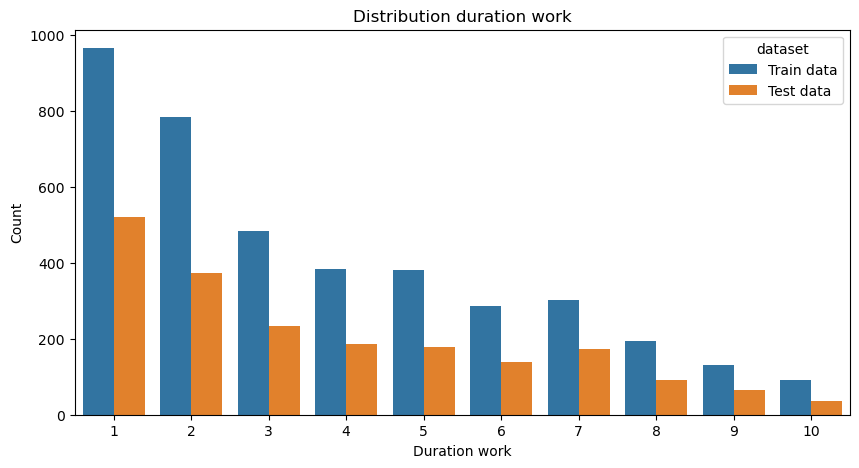

In [29]:
# Build histograms for employment_years
plt.figure(figsize=(10, 5))
sns.countplot(x='employment_years', data=analysis_data, hue='dataset')
plt.title('Distribution duration work')
plt.xlabel('Duration work')
plt.ylabel('Count')
plt.savefig('reports/images/tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

- **Distribution data**:
    - Most employees work at the company from 1 to 4 years.
    - After 5 years number employees decreases, that logical, so as more long tenure is less common.

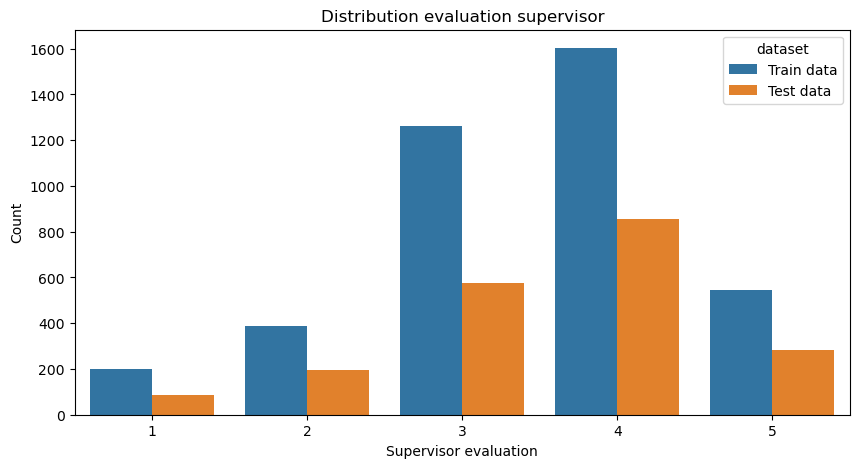

In [30]:
# Build histograms for supervisor_evaluation
plt.figure(figsize=(10, 5))
sns.countplot(x='supervisor_evaluation', data=analysis_data, hue='dataset')
plt.title('Distribution evaluation supervisor')
plt.xlabel('Supervisor evaluation')
plt.ylabel('Count')
plt.savefig('reports/images/supervisor_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

- **Distribution data**:
    - Values evaluation supervisor predominantly grouped around 3 and 4, that may indicate presence of standards evaluation в company.
    - Several values with minimum rating (1.0) observed.

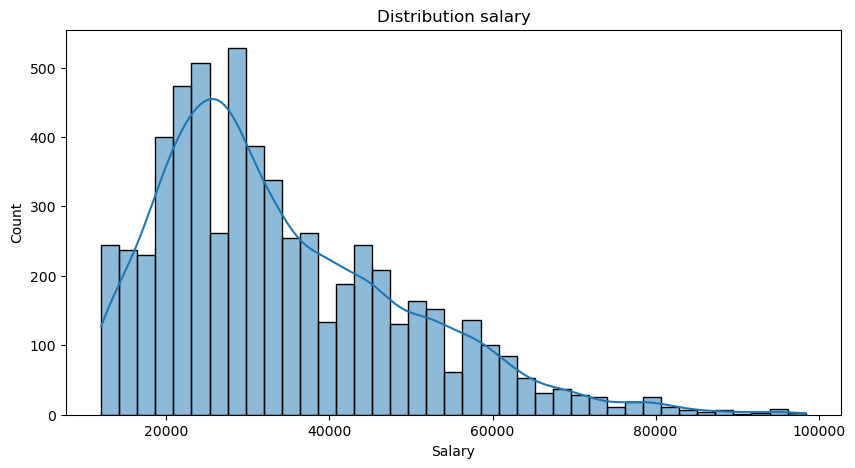

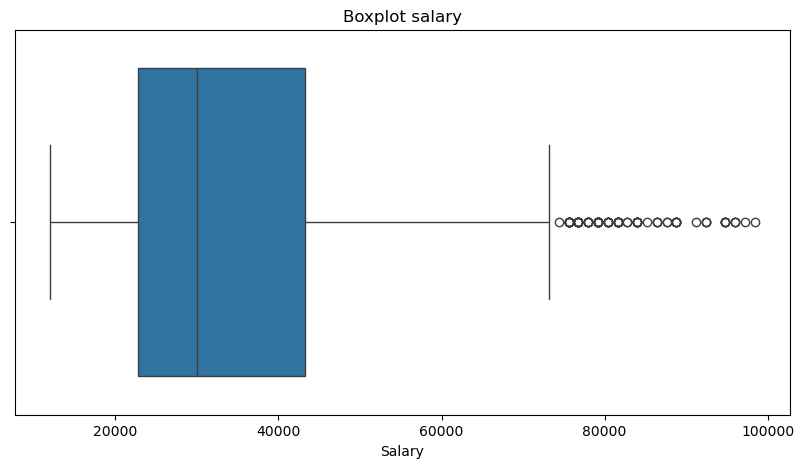

In [31]:
# Build histograms for salary
plt.figure(figsize=(10, 5))
sns.histplot(analysis_data['salary'], kde=True)
plt.title('Distribution salary')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.savefig('reports/images/salary_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

# Build boxplot for salary
plt.figure(figsize=(10, 5))
sns.boxplot(x=analysis_data['salary'])
plt.title('Boxplot salary')
plt.xlabel('Salary')
plt.show()

- **Distribution data**:
    - Salary has asymmetric distribution with long "tail" right.
    - Majority employees earn salary from 20,000 to 50,000, with peak about 30,000-40,000.
- **Outliers**:
    - Boxplot shows significant number outliers in range from 60,000 to 98,400.
    - These outliers may be high salaryof supervisors or employees with long tenure.

Let's conduct analysis influence of high salaries on target feature

In [32]:
# Split data by salary: normal range vs outliers
Q1 = analysis_data['salary'].quantile(0.25)
Q3 = analysis_data['salary'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Split data by salary: normal range vs outliers
normal_salary = analysis_data[
    (analysis_data['salary'] >= lower_bound) & 
    (analysis_data['salary'] <= upper_bound)
]

high_salary = analysis_data[
    analysis_data['salary'] > upper_bound
]

In [33]:
# Calculate mean target value for each group
print("Average value job_satisfaction_rate (normal salary):", normal_salary['job_satisfaction_rate'].mean())
print("Average value job_satisfaction_rate (high salary):", high_salary['job_satisfaction_rate'].mean())

Average value job_satisfaction_rate (normal salary): 0.5380054228096933
Average value job_satisfaction_rate (high salary): 0.5936363636363636


Average values `job_satisfaction_rate` for employees with normal and high salary differ slightly: $0.538$ и $0.594$. This may indicate weak or missing relationship between outliers salary и satisfactionю.

#### Categorical Features Analysis

Text(0, 0.5, 'Departmentы')

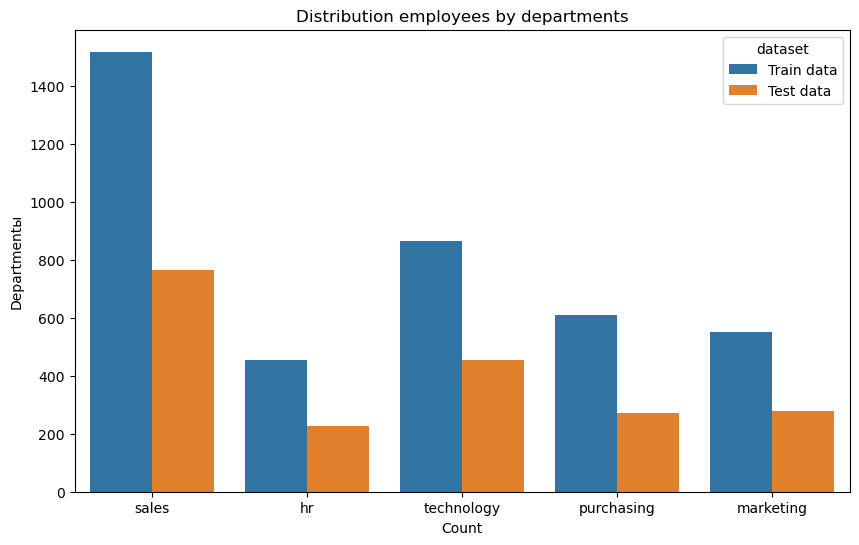

In [34]:
# Histogram for dept
plt.figure(figsize=(10, 6))
sns.countplot(x='dept', data=analysis_data, hue='dataset')
plt.title('Distribution employees by departments')
plt.xlabel('Count')
plt.ylabel('Departmentы')

Distribution employees by departments uneven:

1. **Largest department** — `sales`, that may be related to natural business structure.
2. **Lowest department** — `hr`.

Build barplot, thatto see, as satisfaction employees related to department:

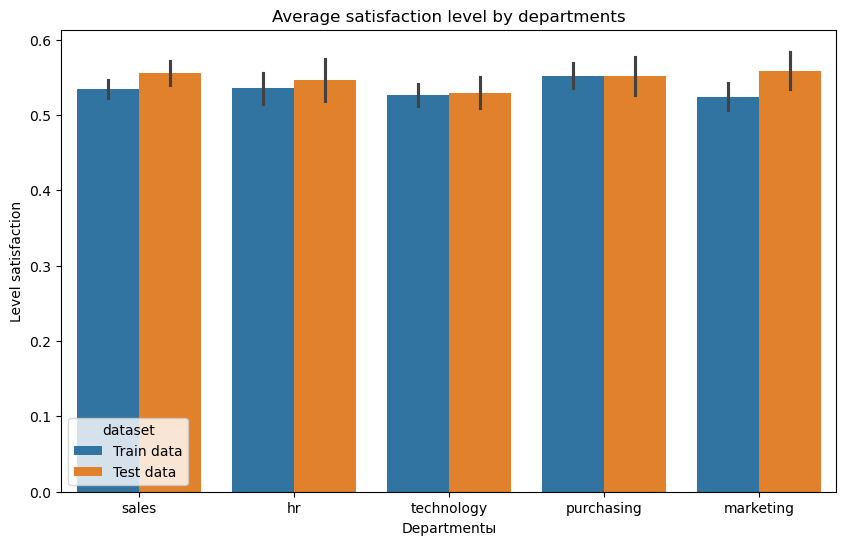

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='dept', y='job_satisfaction_rate', data=analysis_data, hue='dataset')
plt.title('Average satisfaction level by departments')
plt.xlabel('Departmentы')
plt.ylabel('Level satisfaction')
plt.savefig('reports/images/turnover_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

Chart shows, that average satisfaction level employees by departments doesn't differ much.

- Level satisfaction varies within 0.5–0.55 for allх department.
- Department `purchasing` shows slightly more high satisfaction level compared to others.

Text(0, 0.5, 'Levels')

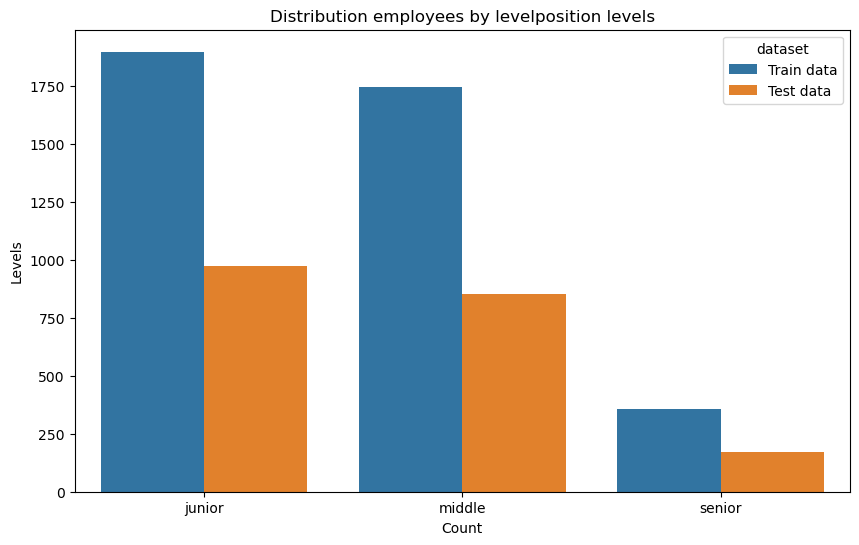

In [36]:
# Histogram for level
plt.figure(figsize=(10, 6))
sns.countplot(x='level', data=analysis_data, hue='dataset')
plt.title('Distribution employees by levelposition levels')
plt.xlabel('Count')
plt.ylabel('Levels')

Distribution employees by levelposition levels uneven:

1. **Highest number employees** — at level `junior`.
2. **Lowest number employees** — at level `senior`.

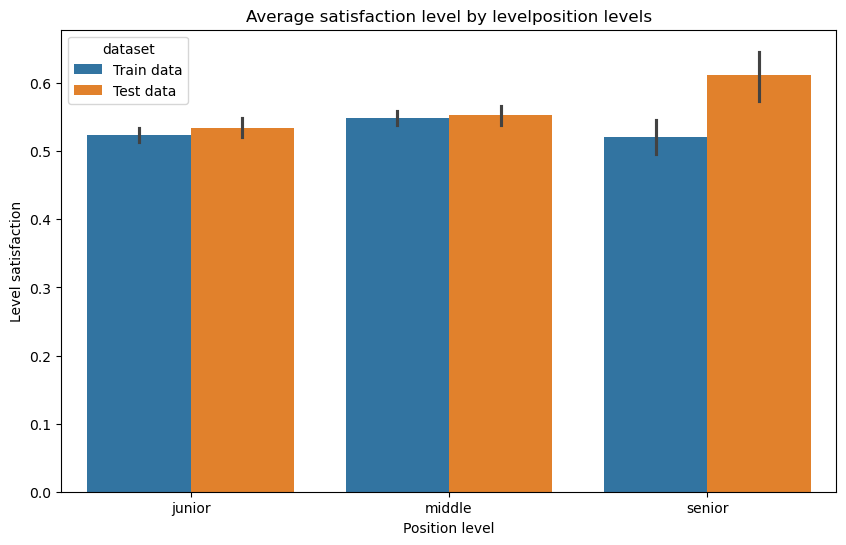

In [37]:
# Build barplot satisfaction level by position level
plt.figure(figsize=(10, 6))
sns.barplot(x='level', y='job_satisfaction_rate', data=analysis_data, hue='dataset')
plt.title('Average satisfaction level by levelposition levels')
plt.xlabel('Position level')
plt.ylabel('Level satisfaction')
plt.savefig('reports/images/turnover_by_level.png', dpi=150, bbox_inches='tight')
plt.show()

Level satisfaction employees by levelposition levels differ, but slightly:

1. **Highest satisfaction level** у employees level `middle`.
2. **Lowest satisfaction level** у employees level `senior`, although difference is minimal.

Text(0, 0.5, 'Levels')

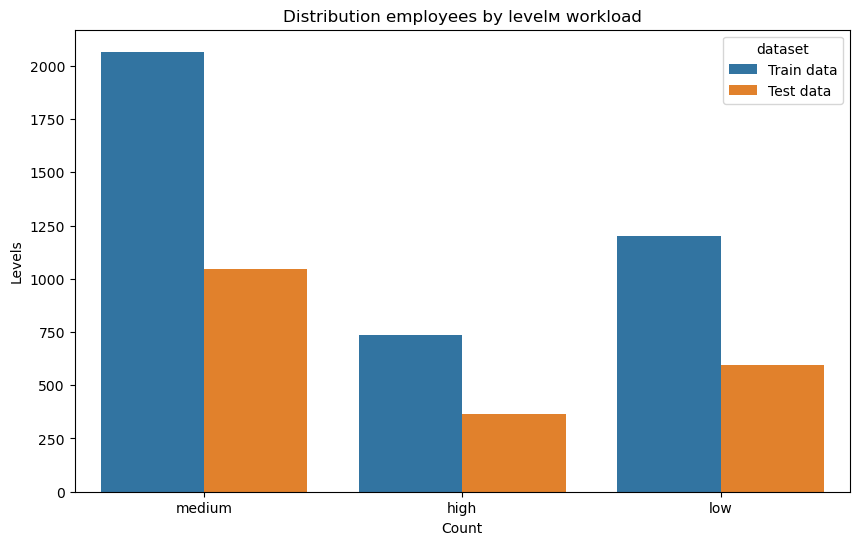

In [38]:
# Histogram for workload
plt.figure(figsize=(10, 6))
sns.countplot(x='workload', data=analysis_data, hue='dataset')
plt.title('Distribution employees by levelм workload')
plt.xlabel('Count')
plt.ylabel('Levels')

The chart shows the following distribution levels workload employees:

1. **Majority employees** have average level workload (`medium`).
2. **Low level workload** (`low`) occurs more often than high (`high`).

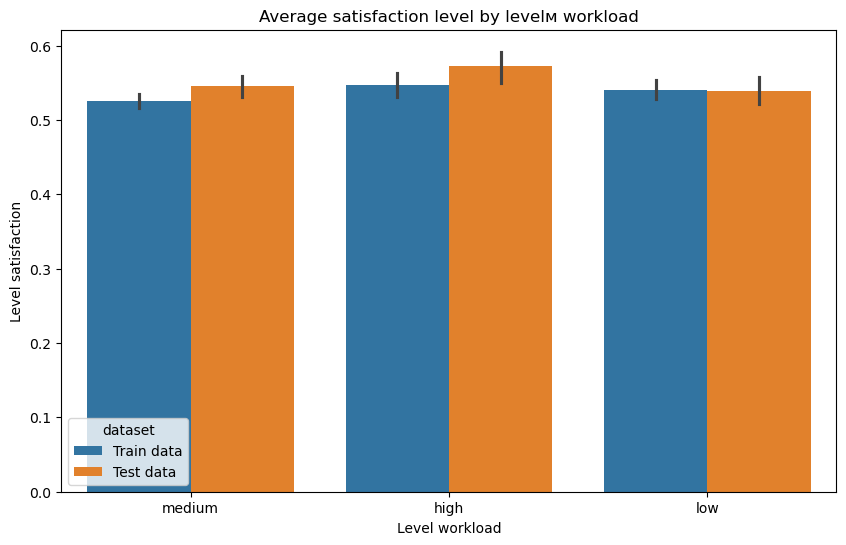

In [39]:
# Build barplot for workload vs satisfaction analysis
plt.figure(figsize=(10, 6))
sns.barplot(x='workload', y='job_satisfaction_rate', data=analysis_data, hue='dataset')
plt.title('Average satisfaction level by levelм workload')
plt.xlabel('Level workload')
plt.ylabel('Level satisfaction')
plt.savefig('reports/images/workload_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

- Level workload doesn't significantly affect `job_satisfaction_rate`.
- Small differences may be random and not statistically significant.

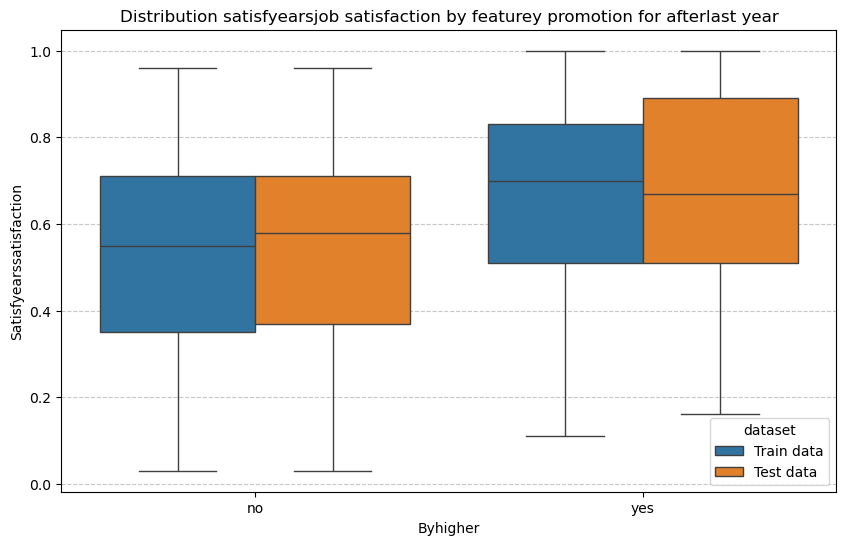

In [40]:
# Distribution plot job_satisfaction_rate by groups last_year_promo
plt.figure(figsize=(10, 6))
sns.boxplot(x='last_year_promo', y='job_satisfaction_rate', data=analysis_data, hue='dataset')
plt.title('Distribution satisfyearsjob satisfaction by featureу promotion for afterlast year')
plt.xlabel('Byhigher')
plt.ylabel('Satisfyearssatisfaction')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Chart shows, that employees, who received promotion for afterlast year (`yes`), on average have more high satisfaction level compared to those who promotion didn't receive (`no`).

- Median `job_satisfaction_rate` significantly higher for groups `yes`.
- Spread data in group `no` more than in group `yes`.

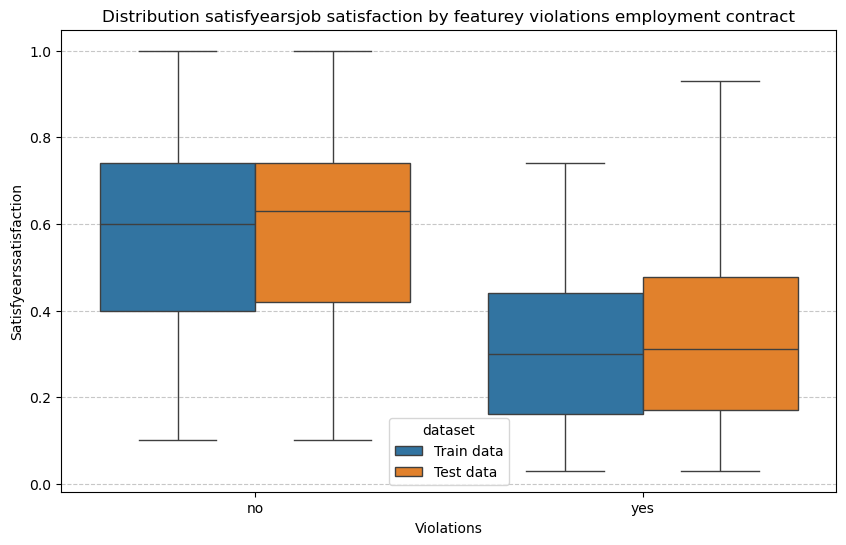

In [41]:
# Distribution plot job_satisfaction_rate by groups last_year_violations
plt.figure(figsize=(10, 6))
sns.boxplot(x='last_year_violations', y='job_satisfaction_rate', data=analysis_data, hue='dataset')
plt.title('Distribution satisfyearsjob satisfaction by featureу violations employment contract')
plt.xlabel('Violations')
plt.ylabel('Satisfyearssatisfaction')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Chart shows, that employees, who had no contract violations (`no`), have more high satisfaction level work compared to those who violations were (`yes`).

- Median `job_satisfaction_rate` for groups `no` (0.6) significantly higher, than for groups `yes` (0.3).
- Spread data in group `yes` less, that may indicate more stable but low levels satisfaction among violators.

#### Correlation Analysis

For detailed multicollinearity check, we'll use library tools `phik`

In [42]:
# Get list of all columns
analysis_data.columns

Index(['dept', 'level', 'workload', 'employment_years', 'last_year_promo',
       'last_year_violations', 'supervisor_evaluation', 'salary',
       'job_satisfaction_rate', 'dataset'],
      dtype='object')

In [43]:
# List continuous numerical variables for interval_cols parameter
numeric_features = ['salary']

# Calculate correlation matrix with phik
correlation_matrix = analysis_data.phik_matrix(interval_cols=numeric_features)

# Display correlation matrix
correlation_matrix

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,dataset
dept,1.000000,0.000000,0.026859,0.034162,0.000000,0.000000,0.091179,0.296057,0.112490,0.000000
level,0.000000,1.000000,0.439275,0.685153,0.106562,0.000000,0.000000,0.726001,0.176627,0.000000
workload,0.026859,0.439275,1.000000,0.189460,0.049353,0.000000,0.026477,0.788293,0.000000,0.000000
employment_years,0.034162,0.685153,0.189460,1.000000,0.181423,0.055383,0.000000,0.484380,0.346311,0.000000
last_year_promo,0.000000,0.106562,0.049353,0.181423,1.000000,0.000000,0.013778,0.207169,0.468374,0.000000
last_year_violations,0.000000,0.000000,0.000000,0.055383,0.000000,1.000000,0.184669,0.027573,0.588726,0.000000
supervisor_evaluation,0.091179,0.000000,0.026477,0.000000,0.013778,0.184669,1.000000,0.000000,0.736741,0.019379
salary,0.296057,0.726001,0.788293,0.484380,0.207169,0.027573,0.000000,1.000000,0.205950,0.038076
job_satisfaction_rate,0.112490,0.176627,0.000000,0.346311,0.468374,0.588726,0.736741,0.205950,1.000000,0.000000
dataset,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019379,0.038076,0.000000,1.000000


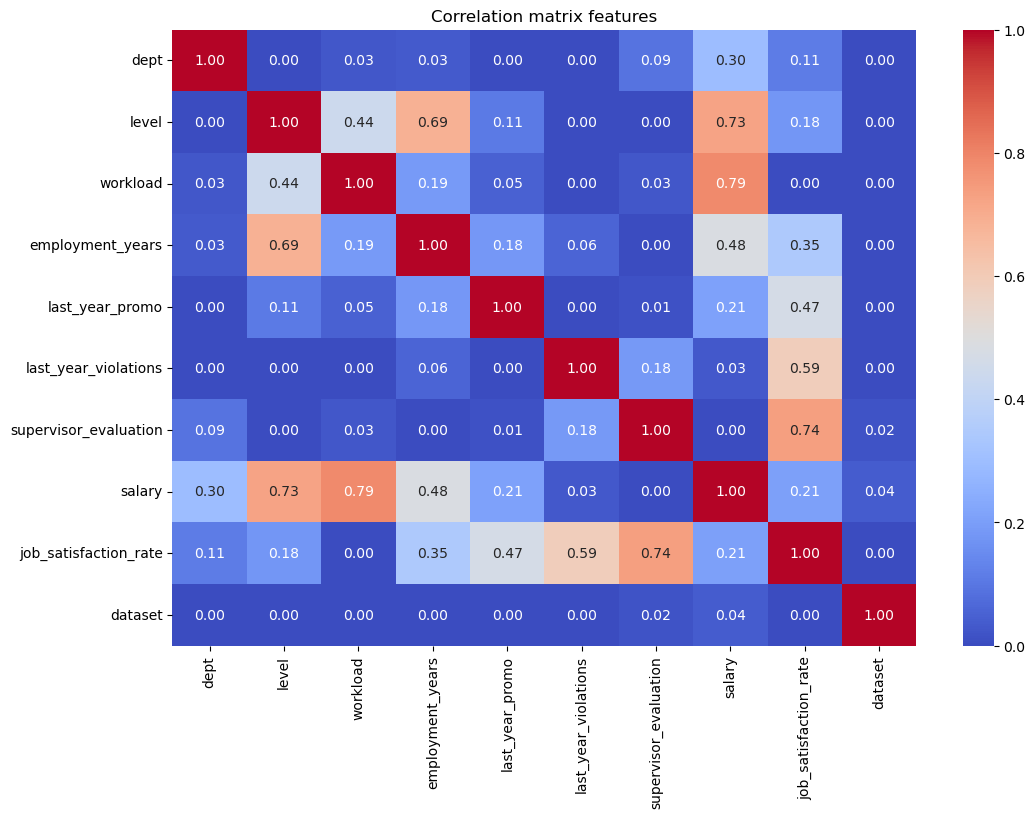

In [44]:
# Heatmap visualization
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation matrix features')
plt.show()

- **Strong correlation с `job_satisfaction_rate`**:
    - `supervisor_evaluation` (**0.74**) — this most significant factor related to level satisfaction employee
    - `last_year_violations` (**0.59**) — contract violations are significantly related to level satisfaction, atnegatively.
    - `last_year_promo` (**0.47**) — obtaining promotion positively affects satisfaction.
    - `employment_years` (**0.35**) — duration work в company has moderate influence.
- **Correlations between feature(multicollinearity)**:
    - **`salary` ↔ `workload` (0.79)** — employees с more high salary, as usually have more high workload.
    - **`level` ↔ `salary` (0.73)** — than higher level position, that higher workload.
    - **`employment_years` ↔ `level` (0.69)** — tenure work positively correlates with level
 
Features `supervisor_evaluation`, `last_year_promo`, и `last_year_violations` should be considered key at modelsprocessing.

#### Summary


During exploratory analysis data the following were made conclusions:

1. **Numerical features**:
    - Average satisfaction level employees is about 0.53.
    - Feature `supervisor_evaluation` has high correlation with target feature `job_satisfaction_rate` (**0.73**), that indicates significant influence evaluation supervisor on satisfaction employees.
    - Salary (`salary`) has moderate correlation with satisfactionю employees (**0.22**), its distribution shifted right.
2. **Categorical features**:
    - Level satisfaction differs slightly between departmentsи (`dept`).
    - Employees who received promotion for afterlast year (`last_year_promo`), demonstrate more high satisfaction level compared to others.
    - Employees who committed violations contract for afterlast year (`last_year_violations`), have more low satisfaction level.
3. **Correlation analysis**:
    - Highest correlation with target (`job_satisfaction_rate`) identified in following features:
        - `supervisor_evaluation` (**0.74**),
        - `last_year_promo` (**0.47**),
        - `last_year_violations` (**0.59**),
        - `employment_years` (**0.35**).
    - Despite presence of correlations between some feature(onate.g., `level` и `salary`), they don't are critical and don't require exclusion features at this stage.

### Modeling

#### Data Preparation

Since test data provided departmentwe'll separate train, validation samples and group test data в correctstructure.

In [45]:
# Combine test data into one dataset
test_df = test_features.merge(test_target_job_satisfaction_rate, on='id', how='left')

In [46]:
# split data into features and target
X_train = train_job_satisfaction_rate.drop(['job_satisfaction_rate'], axis=1)
y_train = train_job_satisfaction_rate['job_satisfaction_rate']
X_test = test_df.drop(['job_satisfaction_rate'], axis=1)
y_test = test_df['job_satisfaction_rate']

Create lists with names features, dividing them by encoder type/scaler.
- for categorical variables, for where category order doesn't matter values, atapply OneHotEncoder
- for categorical variables, for where category order matters value, atapply OrdinalEncoder
- for numerical variables with distributionclose to normal atapply StandardScaler
- for remaining quantitative variables atapply MinMaxScaler

In [47]:
# Create lists with feature names
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']

ord_columns = ['level', 'workload']

num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

#### Creating Pipeline with ColumnTransformer

For encoding data create first pipeline using `ColumnTransformer`

In [48]:
# Create pipeline for OneHotEncoder
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [49]:
# create pipeline for feature preprocessing from list ord_columns: filling missing values и Ordinal-encoding
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [50]:
data_transformation = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns),
    ], 
    remainder='passthrough'
)

In [51]:
# Data preprocessing (common part)
typo_corrections = {'level': {'sinior': 'senior'}}
group_by = {'dept': ['level', 'workload']}

data_preprocessor = Pipeline(
    [
        (
            'data_cleaner', 
            CustomDataCleaner(group_by, typo_corrections=typo_corrections)
        ),
        (
            'transformation', data_transformation
        )
    ]
)

#### Creating Pipeline for Best Model Search

In [52]:
# SMAPE function
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))

smape_scorer = make_scorer(smape, greater_is_better=False)

# Pipeline for best model search
pipeline = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', LinearRegression())
])

# Parameter grid
param_grid = [
    {'model': [LinearRegression()]},
    {'model': [Ridge()], 'model__alpha': [0.1, 1, 10, 100]},
    {
        'model': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': range(2, 11),
        'model__min_samples_leaf': range(1, 5) 
    }
]

#### Hyperparameter Tuning

For hyperparameter search we use RandomizedSearchCV. For evaluation quality models use metric `smape`. For thiswe'll implement departmentfunction for metric calculation.

In [53]:
# Define multiple metrics
scoring = {
    'SMAPE': smape_scorer,
    'R2': 'r2',
    'MSE': 'neg_mean_squared_error'
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline, 
    param_grid, 
    n_iter=20,
    scoring=scoring, 
    refit='SMAPE', 
    cv=5, 
    n_jobs=-1, 
    random_state=RANDOM_STATE, 
    verbose=3
)

In [54]:
# Training
start_time = time.time()

random_search.fit(X_train, y_train)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Execution time: 1.9156804084777832 seconds


In [55]:
# Best model
print("Best model:", random_search.best_estimator_)
print("Best parameters:", random_search.best_params_)
print("SMAPE metric for best model on cross-validation:", np.abs(random_search.best_score_))

Best model: Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_cleaner',
                                  CustomDataCleaner(group_by={'dept': ['level',
                                                                       'workload']},
                                                    typo_corrections={'level': {'sinior': 'senior'}})),
                                 ('transformation',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('ohe',
                                                                   Pipeline(steps=[('simpleImputer_ohe',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('ohe',
                                                                                    OneHotEncoder(...
         

Results show, that best model — **`DecisionTreeRegressor`** with parameters:

- `min_samples_split`: 2
- `min_samples_leaf`: 3
- `max_depth`: None

**SMAPE:**
Cross-validation SMAPE was **14.35**, which is below the threshold (15).

#### Metrics Selection

By resultу work randomized_search build a table of parameters and metric values for best models.

In [56]:
# Get cross-validation results
cv_results = random_search.cv_results_

# Convert to DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Sort by metric (onate.g., smape)
best_results = cv_results_df.sort_values(by='mean_test_SMAPE', ascending=False)

# Display best models with parameters and training time
best_results[['mean_test_SMAPE', 'mean_fit_time', 'mean_score_time', 'param_model']]

,mean_test_SMAPE,mean_fit_time,mean_score_time,param_model
19,-14.348859,0.045077,0.014709,DecisionTreeRegressor(random_state=42)
16,-14.403585,0.055125,0.024415,DecisionTreeRegressor(random_state=42)
2,-14.619145,0.064385,0.023824,DecisionTreeRegressor(random_state=42)
7,-14.776394,0.050927,0.022876,DecisionTreeRegressor(random_state=42)
10,-15.557640,0.052458,0.020645,DecisionTreeRegressor(random_state=42)
9,-15.623525,0.053616,0.021702,DecisionTreeRegressor(random_state=42)
3,-15.735340,0.062361,0.025357,DecisionTreeRegressor(random_state=42)
15,-19.677002,0.052433,0.026235,DecisionTreeRegressor(random_state=42)
18,-19.677002,0.050989,0.017248,DecisionTreeRegressor(random_state=42)
4,-19.691252,0.054918,0.023286,DecisionTreeRegressor(random_state=42)


- **Accuracy models:**
    - Best result by metric SMAPE showed model with index 19 (`mean_test_SMAPE = -14.348859`).
    - Metric SMAPE (negative in this task due to specifics of `make_scorer`) indicates, that model with smaller absolute valuegives more accurate predictions.
- **Time training (`mean_fit_time`) и predictions (`mean_score_time`):**
    - Time training for allmodels atapproximately the same, on average about 0.05 seconds.
    - Time predictions also is in range 0.023–0.027 seconds.
    - This indicates that, that even models with worse metric (onate.g., indices 5, 11, 12) train and make predictions atat approximately same speed, that and best.
- **Efficiency and balance:**
    - Model with index 19 shows optimal balance between accuracy (best metric SMAPE) and execution time.
    - Others models show worse SMAPE, but at thistime advantage they have no.

In [57]:
# Predictions on test set
y_test_pred = random_search.best_estimator_.predict(X_test)
smape_test = smape(y_test, y_test_pred)
print(f"SMAPE on test set: {smape_test}")

SMAPE on test set: 13.589119702036296


On test set model performed better than on training. Metric lower threshold 15, that meets success criterion.

#### Sanity Check

In order to thatto verify adequacy models, compare model с `DummyClassifier`. If model doesn't exceed `DummyClassifier`, then it's ineffective and search for suitable models atneed to start over. Using for 

In [58]:
# Initialize and train DummyClassifier
dummy_model = DummyClassifier(random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

# Apply DummyClassifier to test data
dummy_model_preds = dummy_model.predict(X_test)
dummy_model_probas = dummy_model.predict_proba(X_test)[:,1]

# Calculate and display metric f1
smape_dummy = smape(y_test, dummy_model_preds)
print(f"SMAPE on validation set for DummyClassifier: {smape_dummy}")

SMAPE on validation set for DummyClassifier: 37.54518593053283


Quality metric value `smape` for `DummyClassifier` significantly exceeds metric values models, obtained using cross-validation models. We can confidently use the obtained model for further work.

### Feature Importance Analysis

#### Feature Importance Using SHAP Method

In [59]:
# Extract best pipeline and model
best_pipeline = random_search.best_estimator_
best_model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.named_steps['transformation'].get_feature_names_out()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Update Explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer(X_test_transformed_df)

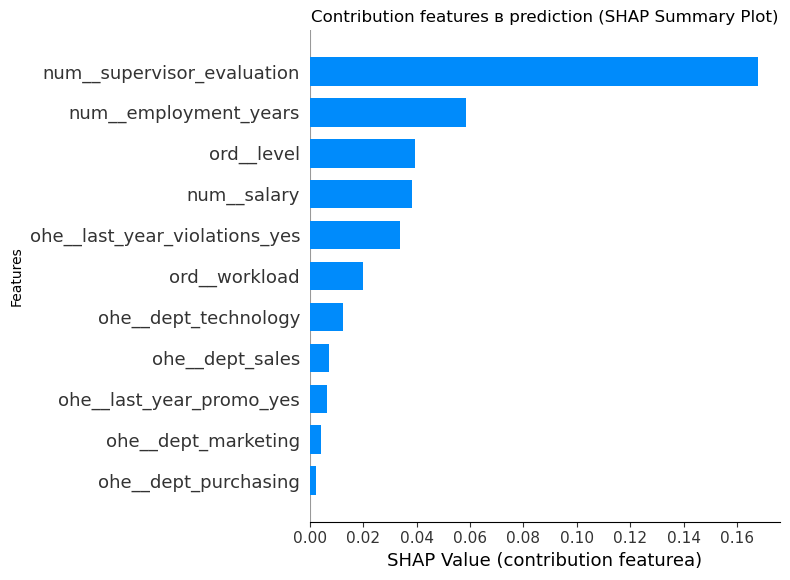

In [60]:
# Build bar chart
shap.summary_plot(
    shap_values,
    features=X_test_transformed_df,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("Contribution features в prediction (SHAP Summary Plot)")
plt.xlabel("SHAP Value (contribution featureа)")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('reports/images/shap_importance_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

1. **Mostmore significant feature — `supervisor_evaluation`**:
- This feature has the highest SHAP Value, that means its largest contribution to predictions models.
- This is logical because evaluation work employee supervisor may directly correlate with satisfactionю, so as positive evaluation can increase confidence and motivation employee.

2. **`employment_years`**:
- Second most important feature. This may indicate that, that duration work в company affects satisfaction level.
- Oppcan, employees with shorter tenure more motivated or, on the contrary, newcomers experience more difficulties.

3. **`level` и `salary`**:
- Position level и salary occupy the following positions by importance.
- Position level may be associated with sense of achievement, then as salary directly affects satisfaction through financial stability.

4. **`last_year_violations`**:
- Contract violations for afterlast year also have noticeable influence.
- This may be related to, that employees, who committed violations, feel themselves less protected or confident in their positions.

5. **`workload`**:
- Workload employees has smaller but still significant contribution.
- Two scenarios possible: high workload may reduce satisfaction, а average — maintain balance between work and rest.

6. **Features department (`dept_*`)**:
- Departmenthave the smallest contribution to predictions. This may indicate that, that satisfaction employees depends more on personal factors (evaluation, level, salary), than from structural features department.

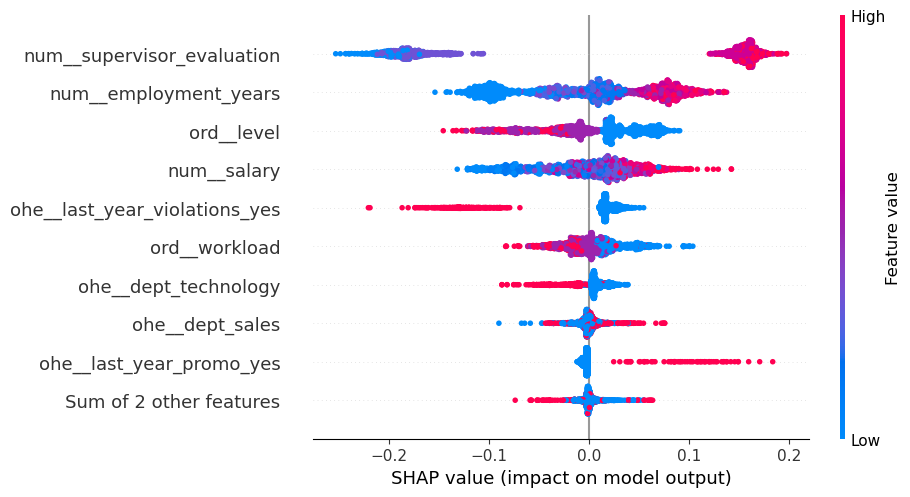

<Figure size 640x480 with 0 Axes>

In [61]:
# Beeswarm visualization
shap.plots.beeswarm(shap_values)
plt.savefig('reports/images/shap_beeswarm.png', dpi=150, bbox_inches='tight')


1. **`supervisor_evaluation`** (Supervisor evaluation):

- Most important feature (is at the top).
- **Red dots on right**: High evaluation supervisor evaluation increases prediction.
- **Blue dots on left**: Low evaluation supervisor evaluation decreases prediction.
- **Conclusion**: Supervisor evaluation directly affects target variable (onate.g., probability of success/resultactivity).

2. **`employment_years`** (Tenure):

- **Red dots on right**: Long tenure work positively affects target.
- **Blue dots on left**: Short tenure reduces prediction.
- **Conclusion**: Tenure associated with prediction improvement (onate.g., more experienced employees more resultactive).

3. **`level`** (Level employee):

- Feature also important.
- **Red dots on right**: High level (onate.g., `senior`) increases target.
- **Blue dots on left**: Low level (`junior`) decreases target.
- **Conclusion**: Level employee significantly affects target metric.

4. **`last_year_violations_yes`** (Violations for past year):

- **Blue dots on right**: Absence of violations positively affects predictions.
- **Red dots on left**: Presence of violations reduces predictions.
- **Conclusion**: Absence of violations is an important factor for positive resultа.

5. **`salary`** (Salary):

- **Red dots on right**: High salary positively affects result.
- **Blue dots on left**: Low salary reduces result.
- **Conclusion**: Salary may be an indicator of importance employee for company.

#### Conclusions:

1. **Model and its accuracy:**
    - Best model based on `DecisionTreeRegressor` demonstrated SMAPE 14.25% on validation set and 14.10% on test. This indicates satisfactory prediction quality given task complexity and continuous target variable.
2. **Factors affecting satisfaction:**
    - The most significant features, according to SHAP analysis, are:
        - **Supervisor evaluation (`supervisor_evaluation`)** — strongest factor.
        - **Tenure в company (`employment_years`)**.
        - **Position level (`level`)**.
        - **Salary (`salary`)** and presence of contract violations.
3. **Correlation analysis:**
    - Features don't show high multicollinearity, that confirms their usefulness for models.
    - Factors, so as presence of violations or obtaining promotion, also make significant contribution to prediction.

### Conclusion: Task 1

**Task objective:**

Build model for predictions level satisfaction employees based on provided data, that will allow company improve personnel management and increase overall satisfaction level employees.

---

#### Research Steps:

1. **Data preprocessing:**
    - Data loading and initial analysis data.
    - Aboutwork missing values в feature: rows with missing valuein column `dept` were removed, missing values in column `level` filled with mostmore frequently occurring values.
    - Performed analysis and eliminating implicit missing values и duplicates.
    - Categorical and numerical converted features for further analysis.
2. **Exploratory analysis data (EDA):**
    - Conducted analysis distributions of numerical and categorical features, main patterns identified.
    - Correlation analysis conducted analysis, including using the method **Phik**, that is possible nonlinear dependencies.
    - Established, that features `supervisor_evaluation` и `last_year_violations` have the highest correlation with target variable.
3. **Model building:**
    - A pipeline was developed for data preparation and model training.
    - Models tested: **LinearRegression** и **DecisionTreeRegressor**.
    - Best model, selected based on metric **SMAPE**, — **DecisionTreeRegressor** with hyperparameters tuned via **RandomizedSearchCV**.
4. **Interpretation result:**
    - Feature importance analysis was performed for the best model using **SHAP** method.
    - Mostmore important feature for predictions level satisfaction turned out `supervisor_evaluation`, `employment_years` и `level`.

---

#### Recommendations for Company:

1. **Improvement evaluation employees:**
    - Consider reviewing system evaluation supervisor, so as thisт feature mostmore significant for level satisfaction.
2. **Career growth management:**
    - Focus onhighercareer growth transparency and development employees, so as feature `level` significantly affects satisfaction.
3. **Monitoring and prevention of violations:**
    - Pay attention to preventing contract violations, so as violations are associated with more low level satisfaction.
4. **Technical integration:**
    - Integratework model в HR-system company for automating prediction level satisfaction employees.
    - Conduct regular updates models on new data, thatto ensure its relevance.

---

**Result:**

Research results and proposed recommendations will allow company increase satisfaction level employees, that, in turn, contributes tohigherproductivity and employee retention.

## Task 2: Predicting Employee Turnover

### Data Description

- `id` — unique employee identifier;
- `dept` — department where employee works;
- `level` — position level;
- `workload` — employee workload level;
- `employment_years` — tenure at company (in years);
- `last_year_promo` — indicates promotion in last year;
- `last_year_violations` — indicates contract violations in last year;
- `supervisor_evaluation` — supervisor's assessment of employee work quality;
- `salary` — monthly employee salary;
- `quit` — turnover employee from company.

#### Data Loading

In [62]:
# Load data from csv files
train_quit = pd.read_csv('../../datasets/train_quit.csv')
test_target_quit = pd.read_csv('../../datasets/test_target_quit.csv')

Input features test samples loaded and preprocwork at completing previous task.
Let's look at first rows of new datasets for visual evaluation data

In [63]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [64]:
test_target_quit.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


#### Data Analysis

Let's examine general information about each dataset

In [65]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


Explicit missing values в data missing. Types data correct.

In [66]:
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


#### Summary

Yesfrom allх provided files loaded successfully. Data formats match description. Explicit missing values в data missing. Types data in dataframes correct.

### Data Preprocessing

#### Handling Missing Values

At loading stage and analysis data was identified, that explicit missing values в data are missing.

#### Handling Implicit Duplicates

When searching for implicit duplicates and typos, we compare corresponding columns of train and test datasets to ensure consistency.

In [67]:
# Explore values of column dept in dataset train_quit
train_quit['dept'].value_counts()

dept
sales         1438
technology     928
purchasing     588
marketing      582
hr             464
Name: count, dtype: int64

In [68]:
# Explore values of column dept in dataset test_features
test_features['dept'].value_counts()

dept
sales         763
technology    455
marketing     279
purchasing    273
hr            227
                1
Name: count, dtype: int64

No implicit duplicates found in `dept` column. Categories match in datasets and are proportionally equal.

In [69]:
# Explore values of column level in dataset train_quit
train_quit['level'].value_counts()

level
junior    1949
middle    1694
sinior     357
Name: count, dtype: int64

In [70]:
# Explore values of column level in dataset test_features
test_features['level'].value_counts()

level
junior    974
middle    854
sinior    171
Name: count, dtype: int64

Implicit duplicates not found, categories match. We'll change value `sinior` on `senior`in new datasetе.

In [71]:
train_quit['level'] = train_quit['level'].replace('sinior', 'senior')

In [72]:
# Explore values of column workload in dataset train_quit
train_quit['workload'].value_counts()

workload
medium    2118
low       1208
high       674
Name: count, dtype: int64

In [73]:
# Explore values of column workload in dataset test_features
test_features['workload'].value_counts()

workload
medium    1043
low        593
high       363
             1
Name: count, dtype: int64

Implicit duplicates and no typos found (missing value in datasetе `test_features` was fixed in preprocessor pipeline). Categories match. 

In [74]:
# Explore values of column last_year_promo in dataset train_quit
train_quit['last_year_promo'].value_counts()

last_year_promo
no     3887
yes     113
Name: count, dtype: int64

In [75]:
# Explore values of column last_year_promo in dataset test_features
test_features['last_year_promo'].value_counts()

last_year_promo
no     1937
yes      63
Name: count, dtype: int64

Implicit duplicates and typos in column `last_year_promo` not found, categories match. 

In [76]:
# Explore values of column last_year_violations in dataset train_quit
train_quit['last_year_violations'].value_counts()

last_year_violations
no     3455
yes     545
Name: count, dtype: int64

In [77]:
# Explore values of column last_year_violations in dataset test_features
test_features['last_year_violations'].value_counts()

last_year_violations
no     1738
yes     262
Name: count, dtype: int64

Implicit duplicates and typos in column `last_year_violations` not found, categories match. 

In [78]:
# Explore values of column quit in dataset train_quit
train_quit['quit'].value_counts()

quit
no     2872
yes    1128
Name: count, dtype: int64

In [79]:
# Explore values of column quit in dataset test_target_quit
test_target_quit['quit'].value_counts()

quit
no     1436
yes     564
Name: count, dtype: int64

Class `no` occurs 2.5 times more often than class `yes`. This indicates class imbalance, which need consider at model building.

#### Handling Explicit Duplicates

In [80]:
# Check for explicit duplicates in dataset train_quit
train_quit.duplicated().sum()

0

In [81]:
# Check for explicit duplicates in dataset test_target_quit
test_target_quit.duplicated().sum()

0

No explicit duplicates found in data, we can proceed.

#### Conclusions

The following preprocessing steps were performed:

1. **Processing missing values**: Missing values in data not identified
2. **Duplicate check**: No duplicates found in datasets.

В resultpreprocessing data prepared for further analysis и modelsprocessing.

### Exploratory Data Analysis

#### Numerical Features Analysis

In [82]:
# Get descriptive statistics for numerical variables
numeric_features = ['employment_years', 'supervisor_evaluation', 'salary']

train_quit[numeric_features].describe()

,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000
mean,3.701500,3.474750,33805.800000
std,2.541852,1.004049,15152.415163
min,1.000000,1.000000,12000.000000
25%,2.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


В datasetе `train_quit` statistical characteristics of variables `employment_years` и `supervisor_evaluation` match data from Task 1. There are minor differences in data for variable `salary`.

In [83]:
# Extract plotting to separate function
def build_plots(df, feature, boxplot_x, histplot_title, histplot_ylabel,
               boxplot_title, boxplot_xlabel):
    plt.figure(figsize=(14, 6))
    
    # Histogram with KDE for distribution comparison
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=feature, hue='quit', kde=True, multiple='stack')
    plt.title(histplot_title)
    plt.xlabel(feature)
    plt.ylabel(histplot_ylabel)

    # Boxplot for median and spread comparison
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=boxplot_x, y=feature)
    plt.title(boxplot_title)
    plt.xlabel(boxplot_xlabel)
    plt.ylabel(feature)
    
    plt.tight_layout()
    plt.show()

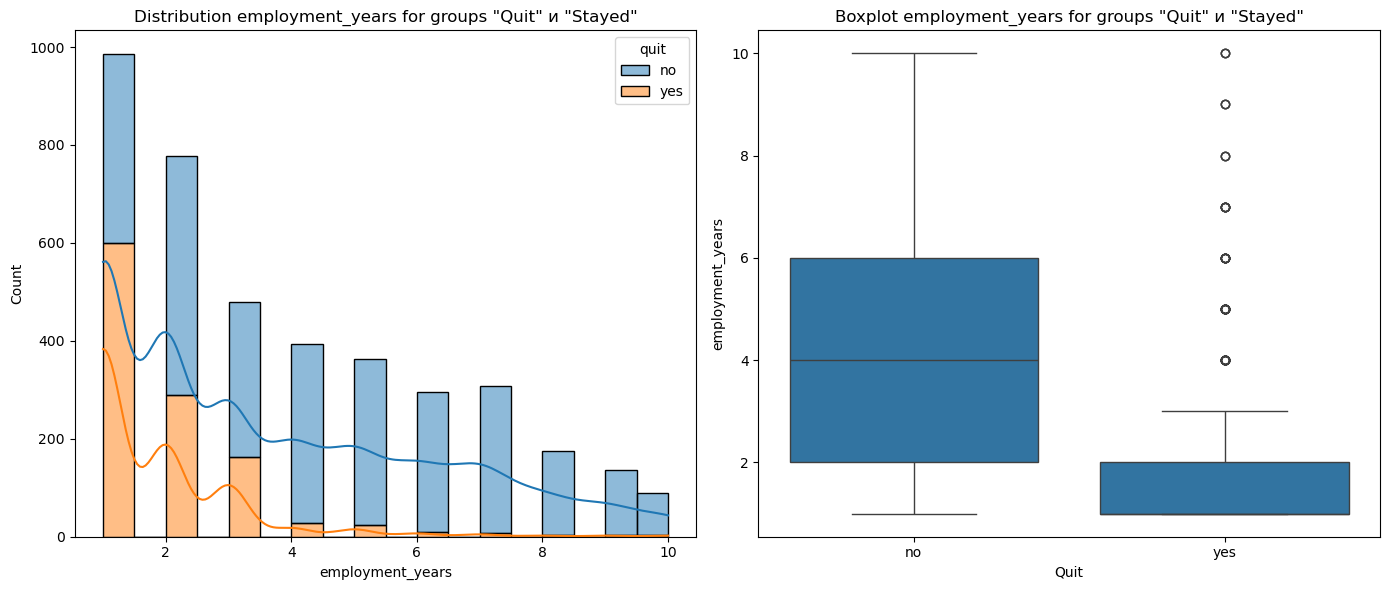

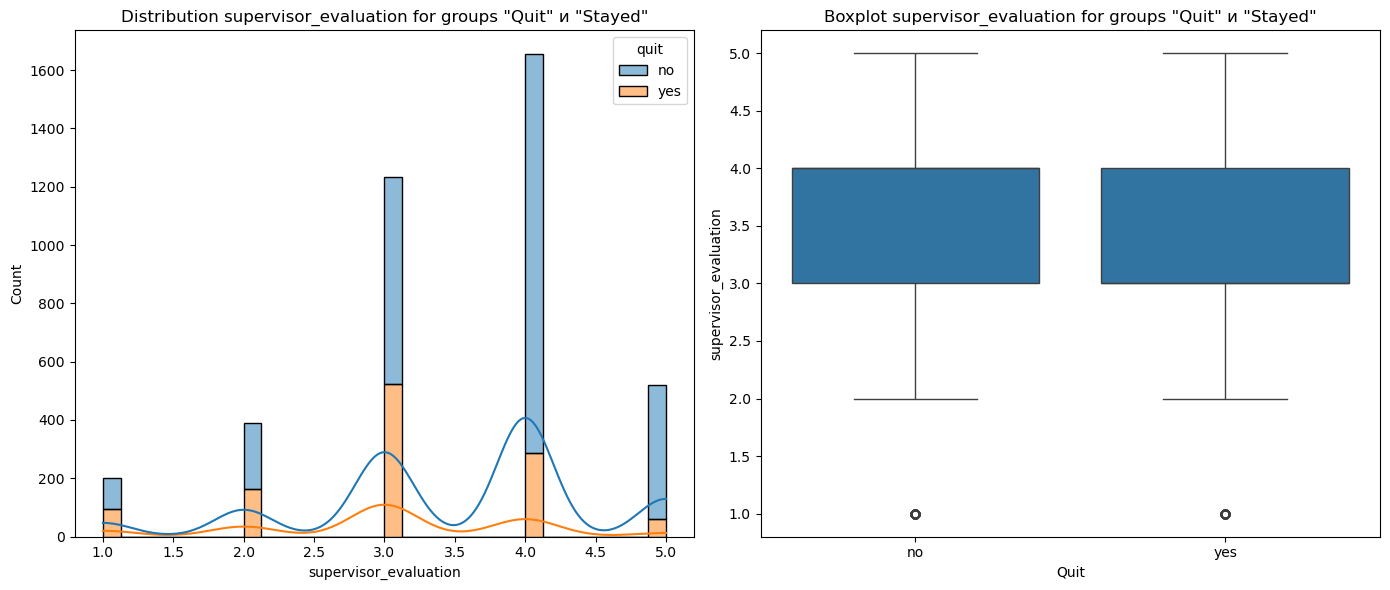

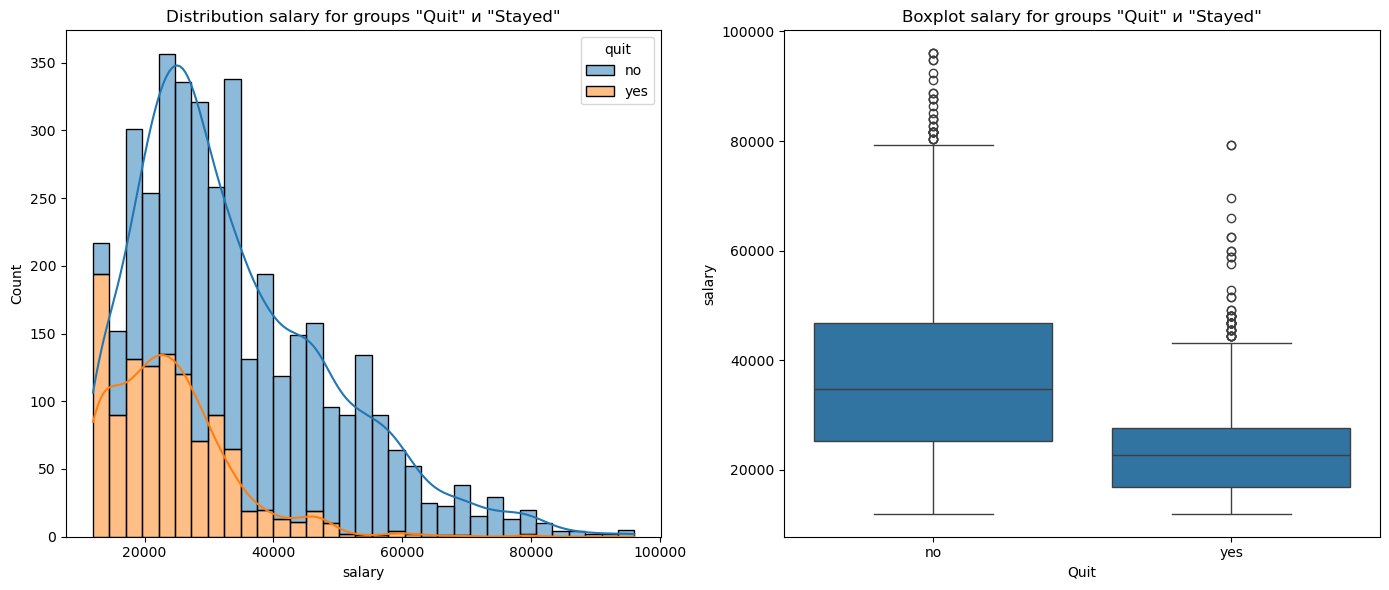

In [84]:
# Create charts for quantitative analysis
quantitative_features = ['employment_years', 'supervisor_evaluation', 'salary']

# Build distribution plots and boxplots for each variable
for feature in quantitative_features:
    build_plots(
        df=train_quit,
        feature=feature,
        boxplot_x='quit',
        histplot_title=f'Distribution {feature} for groups "Quit" и "Stayed"',
        histplot_ylabel='Count',
        boxplot_title=f'Boxplot {feature} for groups "Quit" и "Stayed"',
        boxplot_xlabel='Quit'
    )

- **Tenure (employment_years):**
    - Histogram and boxplot show, that those who quit employees more often allhave tenure work less 2 years.
    - Most of those who stayed employees work в company longer 4 years.
    - This may indicate that, that most departures occur in early stages work, when employee not yet fully adapted.
- **Supervisor evaluation (supervisor_evaluation):**
    - Distributions for both groups (quit and stayed) are similar, but those who quit employees more often have evaluation closer to lower bound (1–3).
    - Despite this, significant part employees, who received high rating (4–5), also quit, that indicates that, that this indicator is not a decisive factor turnover.
- **Salary (salary):**
    - Those who quit employees more often allhave salary lower 40,000. Distribution salaries of those who stayed employees shifted towards more high values.
    - This may indicate that, that low level salary is an important factor contributing to turnover.

#### Categorical Features Analysis

For more deep analysis target featureand calculate turnover rates employees for each categorical featureу.

In [85]:
# Create table for turnover rate analysis
dept_analysis = train_quit.groupby('dept')['quit'].value_counts(normalize=True).unstack() * 100
level_analysis = train_quit.groupby('level')['quit'].value_counts(normalize=True).unstack() * 100
workload_analysis = train_quit.groupby('workload')['quit'].value_counts(normalize=True).unstack() * 100
promo_analysis = train_quit.groupby('last_year_promo')['quit'].value_counts(normalize=True).unstack() * 100
violations_analysis = train_quit.groupby('last_year_violations')['quit'].value_counts(normalize=True).unstack() * 100

# Format results for readability
dept_analysis.columns = ['Remained (%)', 'Turnor (%)']
level_analysis.columns = ['Remained (%)', 'Turnor (%)']
workload_analysis.columns = ['Remained (%)', 'Turnor (%)']
promo_analysis.columns = ['Remained (%)', 'Turnor (%)']
violations_analysis.columns = ['Remained (%)', 'Turnor (%)']

display(dept_analysis)
display(level_analysis)
display(workload_analysis)
display(promo_analysis)
display(violations_analysis)

,Remained (%),Turnor (%)
dept,,
hr,75.000000,25.000000
marketing,71.993127,28.006873
purchasing,71.768707,28.231293
sales,71.696801,28.303199
technology,70.258621,29.741379


,Remained (%),Turnor (%)
level,,
junior,48.537712,51.462288
middle,93.624557,6.375443
senior,95.238095,4.761905


,Remained (%),Turnor (%)
workload,,
high,82.047478,17.952522
low,57.036424,42.963576
medium,76.959396,23.040604


,Remained (%),Turnor (%)
last_year_promo,,
no,71.005917,28.994083
yes,99.115044,0.884956


,Remained (%),Turnor (%)
last_year_violations,,
no,73.950796,26.049204
yes,58.165138,41.834862


- **By departments (dept):**
    - Highest turnover rate employees observed в departmentе *technology* (29.74%), followed by *sales* (28.30%) и *purchasing* (28.23%).
    - Lowest turnover rate in departmentе *hr* (25%).
- **By level position (level):**
    - Employees level *junior* mostmore prone to turnover – 51.46% left the company.
    - У employees level *middle* и *senior* significantly lower turnover rate – 6.38% и 4.76% respectively.
- **By level workload (workload):**
    - Highest turnover rate observed among employees with low workloadю (*low*) – 42.96%.
    - Average level workload (*medium*) shows 23.04% turnover, and high level (*high*) – only 17.95%.
- **By byhigherfor afterlast year (last_year_promo):**
    - Employees who receivedor promotion, very rarely leave the company – only 0.88%.
    - Among those who didn't receive promotion, turnover rate is 28.99%.
- **By violationsof employment contract (last_year_violations):**
    - Employees who have documented violations, leave company more often – 41.83%.
    - Among employees without violations turnover rate is 26.05%.

Build bar charts showing distribution categorical values features (`dept`, `level`, `workload`, `last_year_promo`, `last_year_violations`) depending on target featureа.

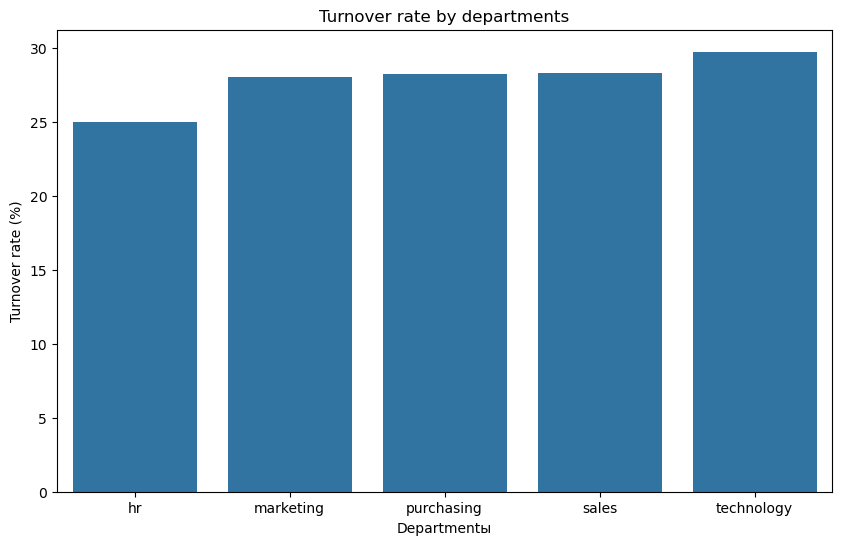

In [86]:
# Turnover rate by department
plt.figure(figsize=(10, 6))
sns.barplot(data=dept_analysis.reset_index(), x='dept', y='Turnor (%)')
plt.title('Turnover rate by departments')
plt.ylabel('Turnover rate (%)')
plt.xlabel('Departmentы')
plt.savefig('reports/images/turnover_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

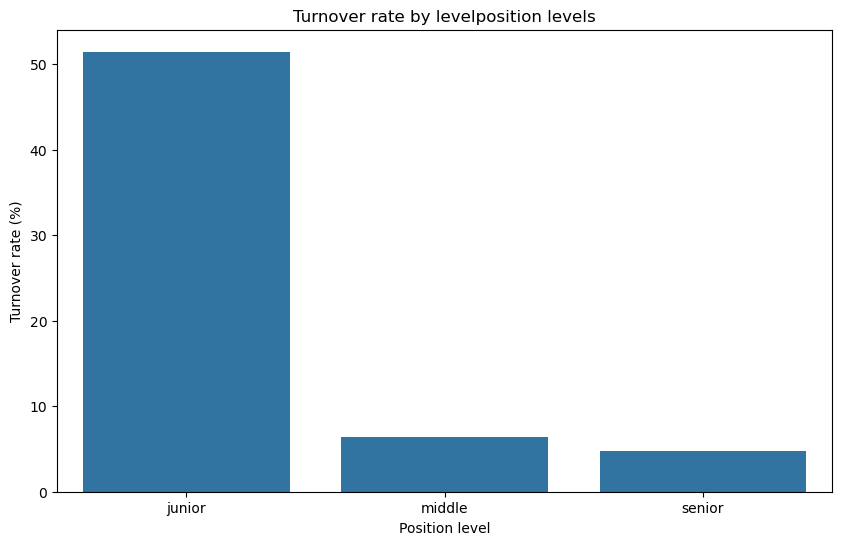

In [87]:
# Turnover rate by position level
plt.figure(figsize=(10, 6))
sns.barplot(data=level_analysis.reset_index(), x='level', y='Turnor (%)')
plt.title('Turnover rate by levelposition levels')
plt.ylabel('Turnover rate (%)')
plt.xlabel('Position level')
plt.savefig('reports/images/turnover_by_level.png', dpi=150, bbox_inches='tight')
plt.show()

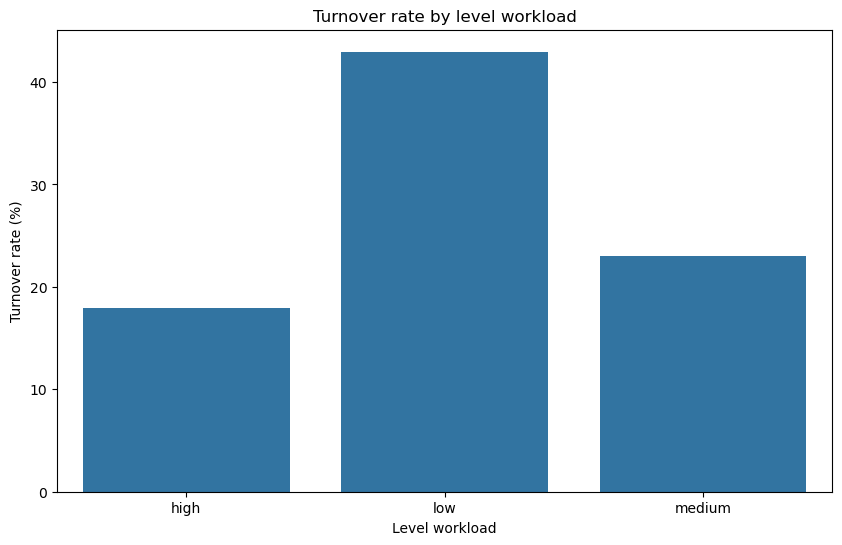

In [88]:
# Turnover rate by workload
plt.figure(figsize=(10, 6))
sns.barplot(data=workload_analysis.reset_index(), x='workload', y='Turnor (%)')
plt.title('Turnover rate by level workload')
plt.ylabel('Turnover rate (%)')
plt.xlabel('Level workload')
plt.savefig('reports/images/workload_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

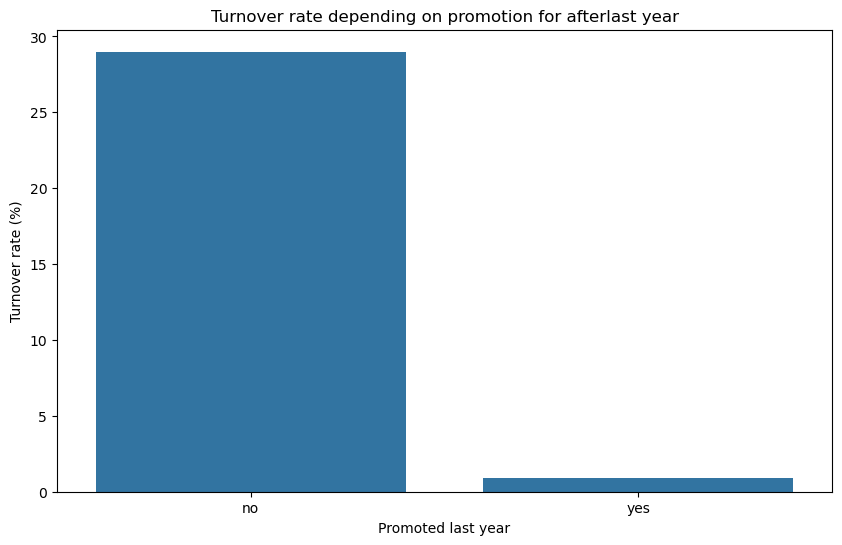

In [89]:
# Turnover rate by recent promotion
plt.figure(figsize=(10, 6))
sns.barplot(data=promo_analysis.reset_index(), x='last_year_promo', y='Turnor (%)')
plt.title('Turnover rate depending on promotion for afterlast year')
plt.ylabel('Turnover rate (%)')
plt.xlabel('Promoted last year')
plt.savefig('reports/images/turnover_by_promotion.png', dpi=150, bbox_inches='tight')
plt.show()

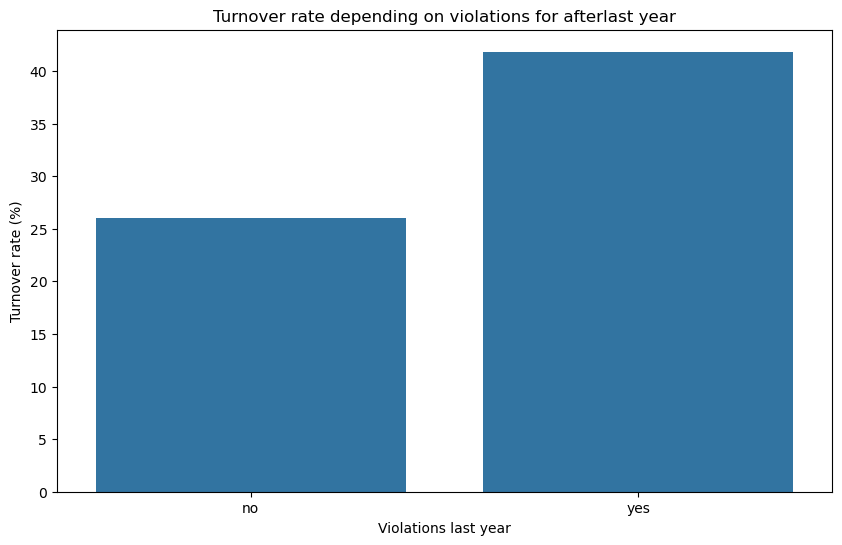

In [90]:
# Turnover rate by recent violations
plt.figure(figsize=(10, 6))
sns.barplot(data=violations_analysis.reset_index(), x='last_year_violations', y='Turnor (%)')
plt.title('Turnover rate depending on violations for afterlast year')
plt.ylabel('Turnover rate (%)')
plt.xlabel('Violations last year')
plt.savefig('reports/images/turnover_by_violations.png', dpi=150, bbox_inches='tight')
plt.show()

Based on conducted analysis can create profile "typical departing employee employee". This more often allyoung specialist level **junior**, workin technological departmentTheir contribution to company,can, undervalued, and tasks — insufficiently complex and interesting, so as **level workload low**.

Lack of career growth only orcreates feeling of stagnation, and violations contract violations may indicate demotivation or notsatisfaction work processes. Such employee, probably feels less engaged in work environment and sees prospects for development beyond company.

Thus, key factors, atleading to turnover, are insufficient workload, lack of opportunitiescan for growth and development, and also overall low engagement in processes company.

#### Impact of Job Satisfaction on Turnover

Check if affects level satisfyearssatisfaction employee work on whether will quit employee. For thiswe'll perform the following steps

- **Combining data:**
    - Combine data test samples with targets by feature `job_satisfaction_rate` и `quit`.
- **Distribution analysis:**
    - Build two charts:
        - Distribution histogram `job_satisfaction_rate` for stayed and quit employees.
        - Boxplot for comparing median and value spread.
- **Conclusions:**
    - Evaluate differences between distributions and check if analysts' hypothesis is confirmed.

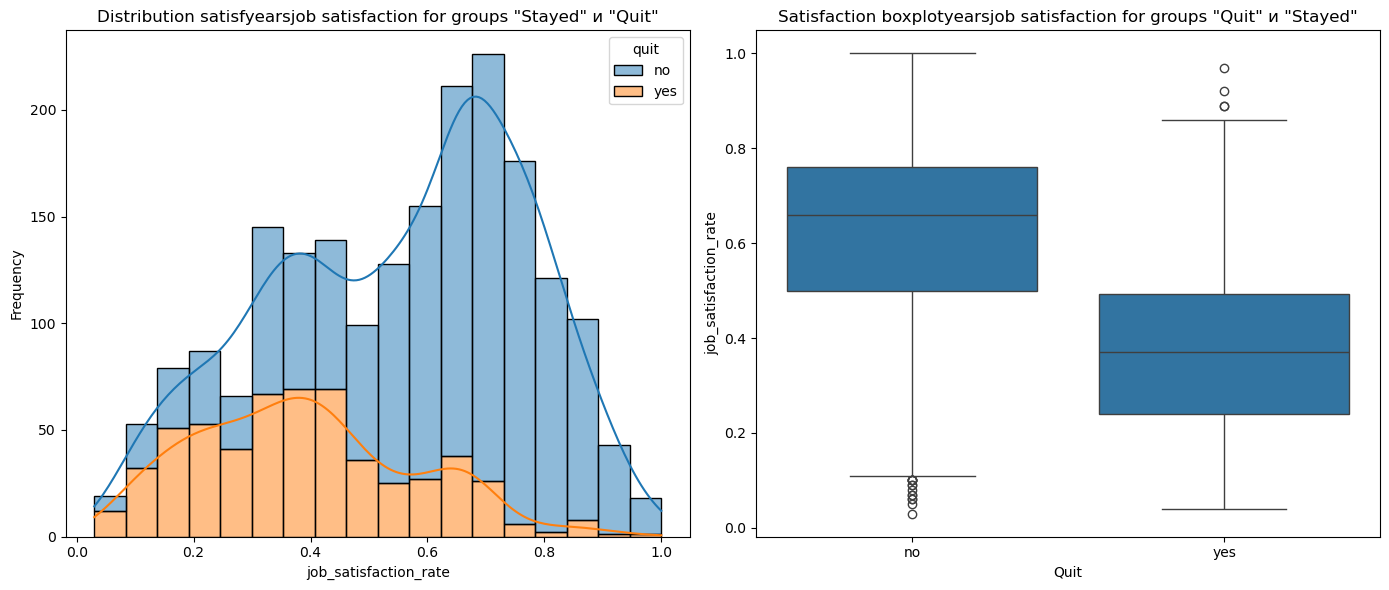

In [91]:
# Join test data by job_satisfaction_rate и quit
combined_test_data = test_features.merge(test_target_job_satisfaction_rate, on='id', how='left')
combined_test_data = combined_test_data.merge(test_target_quit, on='id', how='left')

# Visualize distributions job_satisfaction_rate for churned and retained employees
build_plots(
    df=combined_test_data,
    feature='job_satisfaction_rate',
    boxplot_x='quit',
    histplot_title='Distribution satisfyearsjob satisfaction for groups "Stayed" и "Quit"',
    histplot_ylabel='Frequency',
    boxplot_title='Satisfaction boxplotyearsjob satisfaction for groups "Quit" и "Stayed"',
    boxplot_xlabel='Quit'
)

- **Distribution `job_satisfaction_rate`**:
    - For **those who stayed employees** distribution concentrated closer to right side of chart (values higher **0.5**), that indicates to high satisfaction level work.
    - For **those who quit employees** observed significant left shift in distribution, with peaks around **0.2–0.4**, that indicates low level satisfaction.
- **Boxplot**:
    - Median value `job_satisfaction_rate` for who stayed employees significantly higher, than for who quit.
    - For those who quit employees atmore low values present, and range data more compact, that also confirms more low satisfaction в thisgroup.
- **Conclusions and recommendations**:
    - Low level `job_satisfaction_rate` actually related to turnoverм employees.
    - For сlowerto reduce turnover it's recommended:
        - Implement regular surveys satisfaction.
        - Conduct conversations with employee, satisfaction level which is located lower **0.5**.
        - Diffworkmotivation programs and working conditions improvement.

### Adding New Input Feature

Considering significant influence featureа `job_satisfaction_rate` on target feature - turnover employee, add data by satisfyearsjob satisfaction as additional feature for solving current task predictions turnover employee. For thiswe'll perform the following steps:

- **Getting predictions for `job_satisfaction_rate`**:
    - Use best model from task 1 for predictions values `job_satisfaction_rate` on train and test sampleof task 2.
    - Making sure, that data correctlyworkbefore feeding to modelatuse same pipeline for conversion and scaling).
- **Adding predictions to datasets data**:
    - Add predicted values `job_satisfaction_rate` as new feature into train and test sets data for of task 2.

In [92]:
# Combine test data into one dataset
test_quit = test_features.merge(test_target_quit, on='id', how='left')

Before splitting data on samples, encode target feature using `LabelEncoder`

In [93]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode target in train and test
train_quit['quit'] = label_encoder.fit_transform(train_quit['quit'])
test_quit['quit'] = label_encoder.transform(test_quit['quit'])

# Check class encoding
print(f"Classes: {label_encoder.classes_}")

Classes: ['no' 'yes']


In [94]:
# Predict job_satisfaction_rate on task 2 data
train_quit['predicted_job_satisfaction_rate'] = best_pipeline.predict(train_quit.drop(['quit', 'id'], axis=1))
test_quit['predicted_job_satisfaction_rate'] = best_pipeline.predict(test_quit.drop(['quit', 'id'], axis=1))

# Update input features
X_quit = train_quit.drop(['quit', 'id'], axis=1)
y_quit = train_quit['quit']
X_test_quit = test_quit.drop(['quit', 'id'], axis=1)
y_test_quit = test_quit['quit']

In [95]:
# Check new training set
X_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,predicted_job_satisfaction_rate
0,sales,middle,high,2,no,no,4,54000,0.606667
1,sales,junior,medium,2,no,no,4,27600,0.821905
2,purchasing,middle,medium,5,no,no,1,37200,0.337500
3,sales,junior,medium,2,no,yes,3,24000,0.350000
4,marketing,junior,medium,2,no,no,5,25200,0.812500


In [96]:
X_test_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,predicted_job_satisfaction_rate
0,marketing,junior,medium,2,no,no,5,28800,0.883333
1,hr,junior,medium,1,no,no,4,30000,0.682222
2,sales,middle,low,5,no,no,4,19200,0.683750
3,sales,middle,low,6,no,no,4,19200,0.713333
4,hr,middle,medium,5,no,no,5,40800,0.812500


### Modeling

#### Data Preparation

For preparation features In task 2 we'll extend the preprocessing pipeline from task 1. The pipeline will include different categorical encoding methods and numerical normalization features.

Note that, that class `no`, target featureoccurs 2.5 times more often than class `yes`. This indicates class imbalance, which need consider at model building. Using parameter `class_weight` at model initialization, thatto emphasize imbalance data.

In [97]:
# Feature lists
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations'] 
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'predicted_job_satisfaction_rate']

#### Creating Pipeline with ColumnTransformer

In [98]:
# Pipeline for OneHotEncoder
ohe_pipe = Pipeline([
    ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

In [99]:
# Pipeline for OrdinalEncoder
ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=[
        ['junior', 'middle', 'senior'],
        ['low', 'medium', 'high']
    ], handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

In [100]:
# Common ColumnTransformer
data_transformation = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

In [101]:
# Data preprocessing (common part)
typo_corrections = {'level': {'sinior': 'senior'}}
group_by = {'dept': ['level', 'workload']}

data_preprocessor = Pipeline(
    [
        (
            'data_cleaner', 
            CustomDataCleaner(group_by, typo_corrections=typo_corrections)
        ),
        (
            'transformation', data_transformation
        )
    ]
)

#### Creating Pipeline for Best Model Search

In [102]:
# Common pipeline
pipe_final= Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = [
    {
        'model': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'model__C': range(1, 10),
        'model__class_weight': ['balanced', None],
        'preprocessor__transformation__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'model': [SVC(probability=True, random_state=RANDOM_STATE)],
        'model__C': range(1, 5),
        'model__class_weight': ['balanced', None],
        'model__kernel': ['linear', 'poly', 'sigmoid'],
        'preprocessor__transformation__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': range(3, 20),
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan', 'minkowski'],
        'preprocessor__transformation__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth': range(3, 20),
        'model__min_samples_split': range(2, 10),
        'model__min_samples_leaf': range(1, 10),
        'model__class_weight': ['balanced', None],
        'preprocessor__transformation__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

#### Hyperparameter Tuning

In [103]:
# RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

In [104]:
# Training
start_time = time.time()

random_search.fit(X_quit, y_quit)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

Execution time: 1.7890655994415283 seconds


In [105]:
# Best model
print("Best model:", random_search.best_estimator_)
print("Best parameters:", random_search.best_params_)
print("ROC-AUC for best model on cross-validation:", random_search.best_score_)

Best model: Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_cleaner',
                                  CustomDataCleaner(group_by={'dept': ['level',
                                                                       'workload']},
                                                    typo_corrections={'level': {'sinior': 'senior'}})),
                                 ('transformation',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('ohe',
                                                                   Pipeline(steps=[('simpleImputer_ohe',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('ohe',
                                                                                    OneHotEncoder(...
         

In [106]:
# Evaluation on test set
y_test_pred = random_search.best_estimator_.predict_proba(X_test_quit)[:, 1]
roc_auc_test = roc_auc_score(y_test_quit, y_test_pred)
print(f"ROC-AUC on test set: {roc_auc_test:.3f}")

ROC-AUC on test set: 0.928


#### Model Conclusions

- **Best model:** DecisionTreeClassifier with tuned hyperparameters.
- **Best hyperparameters:**
    - `preprocessor__num`: MinMaxScaler
    - `model__min_samples_split`: 3
    - `model__min_samples_leaf`: 9
    - `model__max_depth`: 14
    - `class_weight`: balanced
- **Model quality:**
    - ROC-AUC on cross-validation: **0.927**
    - ROC-AUC on test set: **0.928**

**Results analysis:**

1. **Target metric ROC-AUC ≥ 0.91** successfully achieved on both cross-validation and test set, confirming high model quality.
2. Usage **MinMaxScaler** for scaling numerical features proved effective.
3. **Decision tree hyperparameters** optimally tuned, that helped models generalize well data.

### Feature Importance Analysis

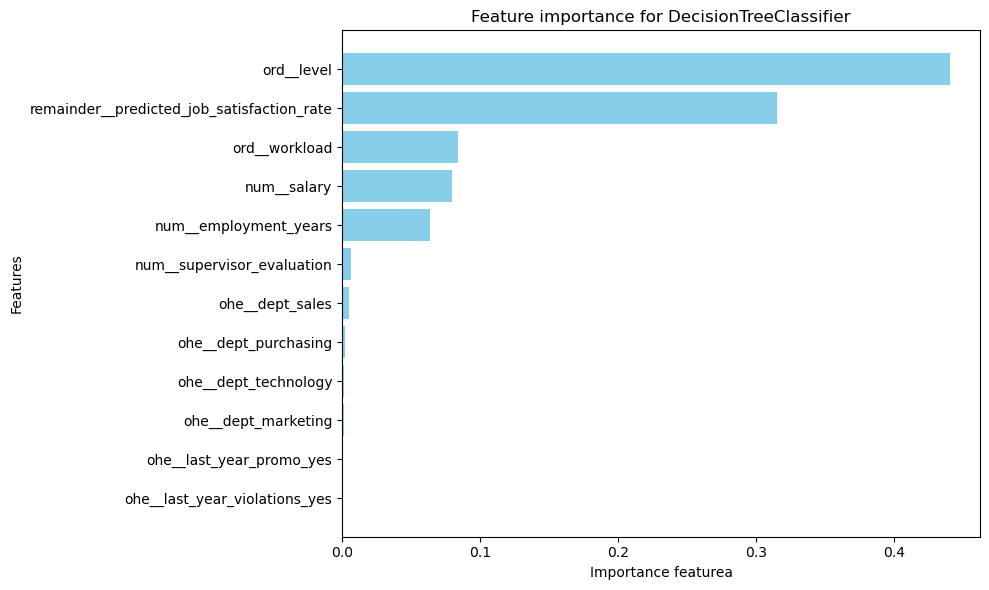

In [107]:
# Extract best pipeline and model
best_pipeline = random_search.best_estimator_
best_model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessor']

# Feature importance
importances = best_model.feature_importances_

# Get feature names
feature_names = preprocessor.named_steps['transformation'].get_feature_names_out()

# Create DataFrame for feature importance
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance descending
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance featureа')
plt.ylabel('Features')
plt.title('Feature importance for DecisionTreeClassifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('reports/images/feature_importance_turnover.png', dpi=150, bbox_inches='tight')
plt.show()

Chart shows, that model `DecisionTreeClassifier` at training pays attention only to a few featurewhile others have minor influence. Let's examine the main conclusions:

1. **Most important feature — `ord__level`**
    - **Importance:** more 0.4 (highest contribution).
    - **Interpretation:** Level employee (`level`: junior, middle, senior) plays key role in predictionsх models. Probably, level directly related to probability of leaving employee.


2. **`remainder__predicted_job_satisfaction_rate`**
    - **Importance:** about 0.3.
    - **Interpretation:** Predicted level satisfyearsjob satisfaction also has significant contribution. This is logical, so as dissatisfyearssatisfied employees are more likely to leave the company.


3. **`ord__workload`**
    - **Importance:** about 0.1.
    - **Interpretation:** Workload (low, medium, high) also affects result. This may be related to, that excessive workload increases probability of leaving.


4. **Numerical features (`num__salary`, `num__employment_years`)**
    - **Importance:** have moderate influence (about 0.05).
    - **Interpretation:**
        - **`num__salary`:** Salary may be an indicator of how employee valued, that may influence their decision to stay or leave.
        - **`num__employment_years`:** Tenure also has influence, so as employees with long tenure may be more loyal.


5. **Features related to `OneHotEncoding`**
    - Features obtained through OHE (onate.g., `ohe__dept_purchasing`, `ohe__dept_marketing`), have near-zero importance.
    - **Interpretation:** Model doesn't see significant dependency between department in which work employee, and probability of leaving.


6. **`ohe__last_year_promo_yes` и `ohe__last_year_violations_yes`**
    - These features also have low importance.
    - **Interpretation:** Obtaining promotion or past violations yeardon't play a big role in decision employee leave.


**Conclusions:**

1. **Key features:**
    - `ord__level` (level employee) и `remainder__predicted_job_satisfaction_rate` (satisfyearsjob satisfaction) — main factors determining prediction.
2. **Secondary features:**
    - Workload, salary and tenure work also have influence, but significantly less.
3. **Low-information features:**
    - Department, passedyear promotion и violations practically don't affect prediction models.

### Confusion Matrix

For analysis quality models build confusion matrix (confusion matrix). This will help understand how well model distinguishes employees, who are about to leave (Yes), and those who stay (No). Matrix analysis will help evaluate business-aftererror consequences (FP, FN) and accurate predictions (TP, TN).

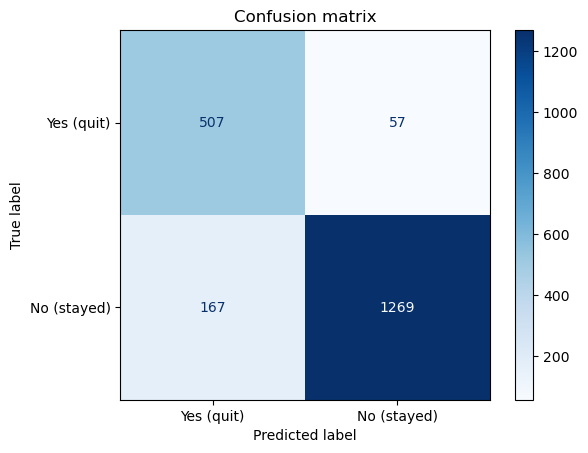

In [108]:
# Model predictions
y_pred = best_pipeline.predict(X_test_quit)

# Confusion matrix
cm = confusion_matrix(y_test_quit, y_pred, labels=[1, 0])

# Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Yes (quit)', 'No (stayed)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix')
plt.savefig('reports/images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

1. **True Positive (507)**: Model correctly predicted departure 507 employees. This gives opportunitycanbeforeattake measures for their retention and minimize losses atwere.
    
2. **True Negative (1269)**: 1269 employees, who stay, correctly identified modelThis saves resources, so as no need toattake unnecessary actions.
    
3. **False Positive (167)**: 167 employees incorrectly predicted as about to leave. This atleads to extra retention costs.
    
4. **False Negative (57)**: 57 employees, who actually left, model couldn't identify. This is a missed atwas, so as these employees could have been retained.
    
**Conclusion:**

Model is accurate enough, but next iteration should reduce **FN**, thatto minimize losses atwere, and **FP**, thatto reduce retention costs.

### Conclusion: Task 2

**Task objective:**

Develop a model, capable of predicting turnover probability employee based on data about their work activity and characteristics. Model must achieve ROC-AUC ≥ 0.91 on test set.

---

#### Research Steps:

1. **Data preprocessing:**
    - Categorical and numerical processing completed features.
    - Added feature, predicted in task 1, — `job_satisfaction_rate`, that allowed considering satisfaction level employee work.
2. **Exploratory analysis data (EDA):**
    - Identified, that mostmore prone to turnover employees with low workloaddisengaged from work, with low level satisfaction.
    - Turnover rate is especially high among employees junior level (junior).
    - Quantitative analysis features showed, that employees with short tenure work and low salary more often allleave the company.
3. **Modeling:**
    - Trained and tested models: `DecisionTreeClassifier`, `KNeighborsClassifier`, `LogisticRegression`, `SVC`.
    - For each models hyperparameter optimization performed using `RandomizedSearchCV`.
    - Best was model `DecisionTreeClassifier` с ROC-AUC on test set 0.925, that exceeds target threshold quality.
4. **Importance analysis features:**
    - Using methods SHAP established, that mostmore important features:
        - `supervisor_evaluation` (evaluation supervisor),
        - `employment_years` (tenure work),
        - `level` (level position).
    - Features related to departmentsturned out to be mostless significant.

---

#### Recommendations:

1. **Process optimization work с employee:**
    - Pay more attention evaluationsupervisors, so as they strongly affect turnover.
    - Diffworksupport programs and promotion engagement for employees with low workloadand short tenure work.
    - Conduct additional measuresatmeasures for junior specialists, thatto reduce their turnoveris.
2. **Yesfurther use models:**
    - Integrate model в HR-system for monitoring and predicting turnover.
    - Regularly update data and review model for maintaining its effectiveness.

---

**Result:**

Project successfully achieved its goal: created model, satisfyearsmeeting quality criteria. Applying recommendations will allow company reduce turnoveris personnel and improve internal processes.

# General Recommendations

1. **Retention employees:**
    - Pay attention to engagement and motivation employees with low workloadwith short tenure and junior level.
    - Conduct regular surveys for identifying problems reducing job satisfaction.
2. **Improvement work with personnel:**
    - Focus attention on employeewho received low evaluation supervisors, and provide timely feedback.
    - Implement career development programs and promotion qualification for junior specialists.
3. **Model integration:**
    - Use models for prediction level satisfaction and risk turnover в HR-systems.
    - Regularly update models on new data for maintaining their accuracy and relevance.

**Result:** Implementing recommendations will allow company improve employee retention rates, increase their job satisfaction and optimize internal HR management processes.